# Group 29 Project


### GROUP MEMBER CONTRIBUTION 

Each of the group member has contributed 25% each  in the project

- Moritz Baldhof : Data exploration and preprocessing 

- Marcell  Hajdú: Data insights and descriptions 

- Jenny Cubelo: Feature selection

- Libero Biagi: Model Selection

The entire project can be found here:
https://github.com/LiberoBiagi/ML_Nova_IMS_25-26

### Abstract

The aim of this project is to create a regression workflow that Cars 4 You can use to improve the efficiency of the car purchase assessment. Currently, the evaluation is performed manually on-site by a qualified mechanic when the car is delivered for purchase. This process is time-consuming and only limitedly scalable. This is also why Cars 4 You is facing significant limitations as customer demand grows. Given this situation, we developed a machine learning pipeline to estimate purchase prices. For this, we evaluated multiple machine learning algorithms, including Linear Regression, Random Forests, and Neural Networks, and different approaches to training them (brand-specific models vs. training on the whole dataset). Our results showed that the Random Forest trained on a brand-specific subset performed most accurately, achieving a Mean Absolute Error of approximately 1100 across all observations. These results provide a good starting point for further business-process optimizations for the car pre-assessment that can be implemented by Cars 4 You. However, we would also like to mention that, even though our approach is achieving good approximation results, the purchasing decision shouldn’t be solely made on the information provided by the model. This is due to a variety of reasons, but the main ones are that the data is entered by the customer and may be biased, and that the model's price estimation is a good approximation, but not a final price suggestion. For the final purchasing process, we recommend a combination of machine learning-based price pre-estimation, which serves as a filter to invite only selected cars for a mechanic's manual inspection, which then determines the final purchase decision and price.

#### Identifying business goals

As a rapidly growing online car resale company, it is important to adjust our business structure and our methods to fit the rampant growth of our customer base. We need to make sure to provide quality service while handling a larger number of customers than ever before. It is in our best interest to keep up the high satisfaction within our customers, to retain our loyal clients.

The growth has exposed a weakness in our current workflow, namely that the waiting times for the car inspections have begun to increase. The capacity of our inspectors is a limiting factor, as it is only possible to inspect a handful of cars every day. Hiring new inspectors would cause a loss in profit, furthermore, it is not a sustainable solution in the long run. 

Our goal is to automate the process of evaluating the cars using predictive machine learning modeling. This would make the evaluation faster, less costly and overall more efficient. The main downside of this technique is that a model will not be able to match the quality of work of a qualified mechanic. It is our goal to create a model, which can produce reliable estimations of the car prices based on their given attributes.

Our approach to this problem is to train different types of machine learning models on our dataset after the neccessary and useful preprocessing steps. We are going to pick the most suitable model based on metrics calculated from a validation set using the holdout method and make our predictions with it. Our main metric will be the mean absolute error (MAE). All of these steps will be done as part of a pipeline in order to streamline the process of the modeling and later the implementation.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

from scipy import stats
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier #, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor

import numpy as np
from sklearn.base import BaseEstimator, clone
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from typing import Dict

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

import random
from copy import deepcopy
import time

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

In [ ]:
import sys
import os

# Add the current directory to sys.path so we can import from Functions
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# Import Preprocessing functions
from Functions.preprocessing import (
    simple_processing, 
    remove_price_outliers, 
    fit_transform_encoding, 
    decode, 
    minimal_features
)

# Import Imputation functions
from Functions.imputation import (
    fit_mode_imputer, 
    apply_mode_imputer, 
    fit_imputer, 
    apply_imputer, 
    fit_price_imputer, 
    apply_price_imputer
)

from Functions.Engineering import *

from Functions.Train import *

from Functions.Selection import *

from Functions.visualization import *

In [3]:
train_df = pd.read_csv("https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/refs/heads/main/data/train.csv")

In [4]:
train_df = train_df.set_index("carID")
train_df = train_df.drop(columns=["paintQuality%"])

In [5]:
#train_df.head()

## Data cleaning

### Workflow for Train and Validation Sets

### Pre-Split Processing
Prior to splitting the data into training and testing splits we need to perform a small number of preprocessing steps to avoid issues after creating the splits. However, for these steps we need to be very careful to avoid data leakage. Thus the performed steps are very limited and strictly limited to not infering any information form the data. The steps we are performing are: 

1. String cleaning
For the string cleaning we use fuzzy matching to correct typos in the data. This is done by using the thefuzz library and the process.extractOne function. We perform this on all the categorical columns in our dataset. Additionally we perform small numeric formating, for example changing the data type for columns or rounding to certain comma digits.

2. Removing Extrem price outliers
In this step we replace extrem price outliers (3* IQR) for each model with missing values. We do this as we believe that these values are not representative of the real data and could be caused by typos or other errors. We thus decided to remove them form the data and later impute them using an Imputer trained on the training data.

3. Fitting and applying the Categorical encoder
Finally, we enode our categorical variables using the LabelEncoder. We do this prior to splitting the data as we need the encoder to see all the possible variables to not face unknown values when decoding the pre-processed data. In this step we get the encoded dataframe as well as the trained encoder which we will later use to decode the training and testing data.

In [6]:
# Fix typos and small numeric cleanup
df = simple_processing(train_df)

# Remove extreme price outliers
df = remove_price_outliers(df)

# Encode categorical columns and replace the str with int columns. Return fitted encoders for decoding at the end
df_encoded, encoders = fit_transform_encoding(df)

We first perform the the simple string and numeric cleaning steps which returns an dataframe with fixed typos (however there are still missing values for the categorical columns). Next we replace each models extrem price outliers with NAs. Finally we fit and apply the Categorical encoder to our data, getting an encoded dataframe and the trained encoder.

### Creating the stratification column
Since we are working with a train/test split for our model training we need to consider a few things to avoid biases in our splits. The main concern we have is that we need to keep a certain balance of prices for each brand, avoidng possible biases in our model. In order to avoid this we use a stratification column combining a categorical price column and the encoded brand column. The combined column will look like this: 
$$
stratification = brand\;encoded + "\_" + price\;categorical
$$

We will use this column to create our train/test split ensuring a balance between prices in the Brands in both of the splits.

In [7]:
# Create Categorical price column with 0 < 1 < 2 for the price
df_encoded["price_cat"] = pd.qcut(df_encoded["price"], 3, labels=False)

# Combine the 10 unique brand values (1-9 & NA) with the 3 unique price category values (0-2)
stratify_col = df_encoded["Brand_transformed"].astype(str) + "_" + df_encoded["price_cat"].astype(str)

As a first step we create the categorical price column, which is an integer ranging from 0 - 2. For this we use qcut to create thre splits of our price column.
Then we combine the categorical price column with the encoded price column to end up with a pd.series which we can use for the stratification of our data.

### Splitting the data

Now we apply the stratification to our data and split it into 80% training and 20% validation. After the split we need to make sure that we fit all the imputer only on the training data and apply the same fitted imputer to the validation and test data. Also we need to delete the price categorical column as we created it prior to splitting the data, which would cause data leakage.

In [8]:
# Train validation split (80/20) split
train_split, validation_split = train_test_split(df_encoded, test_size=0.2, random_state=69, stratify=stratify_col)

# Drop price_cat column from both splits as it would introduce data leakage
train_split = train_split.drop("price_cat", axis=1)
validation_split = validation_split.drop("price_cat", axis=1)

As a result we get two dataframes, one for training the model and one for validation.

### Imputation
After splitting our data we need to work on fixing the remaining missing values. For this we always need to apply the same framework: Fit the imputer on the training data -> Apply it to Training and Validation data. 

For our purpose we use a total of three different imputers: 

1. Mode Imputer: 
The goal of this imputer is to find the missing values in the Brand column for those cases where we have a model name available (Assumption: Each car model is only produced by one brand). We avoid data leakage by getting the most frequent brand for each model from the training data and then applying it to the training and validation data. 

2. Big Imputer: 
This imputer is doing the bulk of the imputing. It is a sklearn IterativeImputer that uses a Extra tree Regressor to impute the missing values. It is trained on the training data and then applied to the training and validation data. We apply this imputer to all columns except the price column, as it is not present in the testing data and thus should not be considered for training the imputer.

3. Price Imputer: 
If we rember from the previous steps we took we removed extrem price outliers, introducing missing values to the price column. As we don't handle these values with our main imputer we need to apply a second imputer to fix these missing values. The imputer we use is a Extra tree Regressor to impute the missing values. It is trained on the training data and then applied to the training and validation data. This imputer is only applied for the training and validation sets as the testing data doesn't have price information.

#### Note: Using Extra Trees over Normal Random Forest for imputing
We decided to use the Extra Trees approach for imputation as it is faster (especially when used with Iterative Imputer) and adds randmization which leades to more diverese trees, decreasing variance and the risk of overfitting. 
Especially the time factor was significant as reaching convergence with the big Imputer is very time consuming.

In [9]:
# Get the most common brand for each model from the train_split
brand_mode_mapping = fit_mode_imputer(train_split)

# Apply mode imputer to both splits using the training mapping
train_split = apply_mode_imputer(train_split, brand_mode_mapping)
validation_split = apply_mode_imputer(validation_split, brand_mode_mapping)


# Train the Big imputer on train
imputer = fit_imputer(train_split)

# Apply trained imputer to both datasplits
imputed_train = apply_imputer(train_split, imputer)
imputed_validation = apply_imputer(validation_split, imputer)

# Impute the missing price values created by removing extrem outliers
# In our step to remove extrem price outliers we introduced missing values in the price column. However, in our normal imputer, which we also use for imputing the test 
# Dataset we can not fix these values as this would cause the imputer to not work on the test subset, with no price feature. 
# Thus we create a seperate price imputer to fix the missing values in the testing and validation sets. This imputer is trained on train and applied to validation
# Fit price imputer
price_imputer = fit_price_imputer(imputed_train)
# Apply price imputer
imputed_train = apply_price_imputer(imputed_train, price_imputer)
imputed_validation = apply_price_imputer(imputed_validation, price_imputer)



c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [10]:
print("Training Data")
print(imputed_train.isna().sum())
print("\n ------------------ \n")
print("Validation Data")
print(imputed_validation.isna().sum())

Training Data
year                        0
mileage                     0
tax                         0
mpg                         0
engineSize                  0
previousOwners              0
stated_no_damage            0
Brand_transformed           0
model_transformed           0
transmission_transformed    0
fuelType_transformed        0
price                       0
dtype: int64

 ------------------ 

Validation Data
year                        0
mileage                     0
tax                         0
mpg                         0
engineSize                  0
previousOwners              0
stated_no_damage            0
Brand_transformed           0
model_transformed           0
transmission_transformed    0
fuelType_transformed        0
price                       0
dtype: int64


After imputing the missing values both our dataframes contain no Missing values and can be decoded.

### Decoding
For the decoding process we use the previously fitted encoders (on the full dataset) and apply them to the train and validation sets.

In [11]:
# Decode encoded columns using the fitted encoders
train_processed = decode(imputed_train, encoders)
validation_processed = decode(imputed_validation, encoders)

The resulting dataframes are fully imputed and cleaned and ready to be used for model training.

## Workflow for Cleaning Testing Dataset

This workflow is to be considered seperate to the train and validation one. Our goal here is to prepair the Testing dataset for prediction, utilising all the information available from the providing training data set.

We use all the information available from the training data sets (train and validation splits) to fit imputers and preprocess the testing dataset. This should create a scenario as close to real world deployment as possible, where we use our existing data to process new data entries.

In [12]:
# Loading the data
test_df = pd.read_csv("https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/refs/heads/main/data/test.csv")

In [13]:
test_df = test_df.set_index("carID")
test_df = test_df.drop(columns=["paintQuality%"]) # Remove paint Quality because Ricardo said so

### Simple pre Imputation processing of Test data

When preprocessing the testing data we try to use all the available data to impute the missing values and processes the dataset as good as possible. Thus we can't simply use the already trained imputer from the train and validation split, as these would not use all the avialable information. Thus we decided to train a new set of imputers trained on all training data and applied to the testing data.

In [14]:
test = simple_processing(test_df)

test_df_encoded, test_encoders = fit_transform_encoding(test)

Same as for the train and validation pipeline we first need to do a simple preporcessing and encode the categorical features.

### Fit the full testing imputer

In the following section we fit all the imputers on the freshly preprocessed training data set. This training data consists on all the available oversavtion, this time not split for train and evaluation samples.   

In [15]:
# Preprocess the full training dataframe from scratch
df = simple_processing(train_df)
df = remove_price_outliers(df)
df_encoded, encoders = fit_transform_encoding(df)

# Fit and apply mode imputer on the full training data
full_brand_mode_mapping = fit_mode_imputer(df_encoded)


# Train a full imputer on the all available training data
full_training_imputer = fit_imputer(df_encoded)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


As the first step we perform the simple preprocessing and encode the dataframe. Next we fit the the mode imputer and the big imputer. We save the fitted imputers to be used on the testing data set. After this fitting step we are ready to processes the real testing data.

### Apply the full imputer to the testing data

After fitting the imputers we apply them to the test set, as well as decode the resulting dataframe. The results is a fully cleaned test set, whith no missing values.

In [16]:
# Apply mode imputer
train_df_mode_imputed = apply_mode_imputer(test_df_encoded, full_brand_mode_mapping)

# Apply imputer trained on testing data
test_df_imputed = apply_imputer(train_df_mode_imputed, full_training_imputer)

test_processed = decode(test_df_imputed, test_encoders)

In [17]:
test_processed.isna().sum()

year                0
mileage             0
tax                 0
mpg                 0
engineSize          0
previousOwners      0
stated_no_damage    0
Brand               0
transmission        0
model               0
fuelType            0
dtype: int64

Looking at the columns of the testing dataset we see that we have filled in all the missing values, making the dataset ready for prediction.

This marks the end of the Preprocessing phase of our notebook. In this section we have processed the train and evaluation datasets, as well as the testing dataset using multiple imputation methods and other preprcessing methods. In the next section we will use the cleaned datasets to engineer new features and train our models.

## Feature Engineering

A preliminary check that may provide useful insight concerns the potential noise introduced by vehicle models that appear in the training set but are absent from the test set.While this mismatch is generally not critical for flexible models such as Random Forests or Neural Networks (which can better generalize across unseen categories)it may be more problematic for simpler models like a single Decision Tree, which are more sensitive to specific splits learned from the training data.



In [18]:
train_val_models = set(pd.concat([train_processed, validation_processed])["model"].unique())
test_models = set(test_processed["model"].unique())

missing_models = train_val_models - test_models


In [19]:
list(missing_models)


['200',
 'kadjar',
 'ranger',
 'getz',
 'urban cruiser',
 'accent',
 'verso-s',
 'caddy maxi',
 '220',
 'streetka',
 's8',
 '230',
 'escort']

As anticipated, we have now obtained the list of models that may introduce issues for certain
algorithms.

Depending on the modeling choices made later in the analysis, we will decide how to handle these
cases. In our specific setup, since we ultimately adopted a Random Forest model, which is relatively
robust to this type of noise, we chose to retain these models in the dataset.


In this section we decided to engineer new features for our dataset. These features are mainly
constructed through mathematical interactions between existing variables or by extracting
statistical information from the data.

The first block of features is composed of the following:

- Age  
  Computed as 2020, the reference year of the dataset, minus the registration year. This feature
  helps amplify differences between older and newer vehicles, which are often strongly related
  to price depreciation.

- Mileage per year  
  Defined as total mileage divided by age plus one. This highlights how intensively a car has been
  used in relative terms, while the plus one avoids division by zero for very recent vehicles.

- Efficiency ratio  
  Measures fuel consumption relative to engine size. This feature captures how efficient a vehicle
  is given its engine displacement, which can influence both running costs and perceived value.

- Age mileage  
  Combines age and mileage to capture absolute usage over time. The division by a scaling factor
  is used to keep the magnitude of the feature comparable to others.

- Age squared  
  Introduced to allow the model to capture nonlinear effects of age on price. Since age is one of
  the most influential variables, adding a polynomial term can improve model flexibility.

- Is premium brand  
  A binary flag indicating whether a car belongs to a brand whose average price is higher than the
  overall dataset average. The motivation and empirical justification for this choice are shown
  in the data visualization section.

Subsequently, we added statistically derived features:

- Model mean price  
  The average price of each model computed on the training set. This was introduced to replace
  the original model categorical variable, which would otherwise generate a very large number of
  one hot encoded features.

- Model standard deviation price  
  Captures the variability of prices within the same model. Some models exhibit large internal
  price dispersion, and providing this information helps the algorithm account for that uncertainty.

- Model median price  
  Similar to the mean price but more robust to outliers, reducing the influence of extreme values
  within a model.

- Brand smoothed mean price  
  This feature is obtained using smoothed mean encoding. For each brand, we compute a weighted
  average between the brand specific mean price and the global mean price of the training set.
  The weighting depends on the number of observations available for that brand.

In [20]:
train_processed.index = train_processed.index.astype(int)
validation_processed.index = validation_processed.index.astype(int)

In [20]:
X_train = train_processed
X_val = validation_processed

In [21]:
X_train = minimal_features(X_train)
X_val = minimal_features(X_val)

In [22]:
model_mean_price = X_train.groupby('model')['price'].mean()
X_train['model_mean_price'] = X_train['model'].map(model_mean_price)
X_val['model_mean_price']   = X_val['model'].map(model_mean_price)

model_std_price = X_train.groupby("model")["price"].std()
model_std_price = model_std_price.fillna(0) 
X_train['model_std_price'] = X_train['model'].map(model_std_price)
X_val['model_std_price'] = X_val['model'].map(model_std_price).fillna(0)

model_median_price = X_train.groupby("model")["price"].median()
X_train['model_median_price'] = X_train['model'].map(model_median_price)
X_val['model_median_price']   = X_val['model'].map(model_median_price)

In [23]:
y_train = X_train['price']
y_val = X_val['price']

In [24]:
X_train, X_val = smoothed_mean_encoding(X_train, X_val, y_train, 'model', m=20)
X_train, X_val = smoothed_mean_encoding(X_train, X_val, y_train, 'Brand', m=50)

In [25]:
X_train = X_train.drop(columns=['price', "model"])

X_val = X_val.drop(columns=['price', "model"])


In [26]:
# Creating the log of our target variable
y_train_log = np.log(y_train)
y_val_log = np.log(y_val)

## Describing our dataset



Showing univariate and multivariate data visualizations in order to get to know our dataset and potential anomalies. We are trying to find out whether our cleaning process was completely succesful and whether our features carry useful information for predictive modeling.

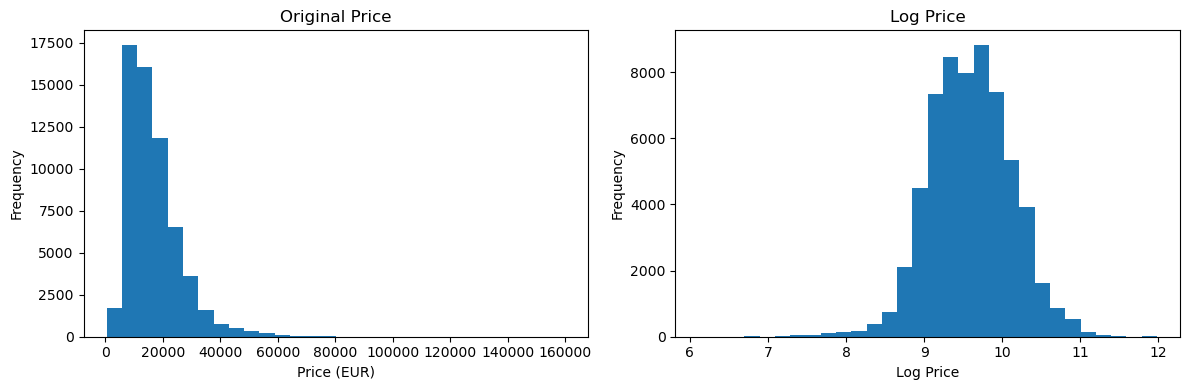

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# First histogram
axes[0].hist(y_train, bins=30)
axes[0].set_title('Original Price')
axes[0].set_xlabel('Price (EUR)')
axes[0].set_ylabel('Frequency')

# Second histogram
axes[1].hist(y_train_log, bins=30)
axes[1].set_title('Log Price')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The distribution of car prices is skewed right, taking the natural logarithm makes it close to symmetrical, it could be worth it keeping it in mind for the modeling for some of our algorithms.

In [28]:
# Displaying basic information about our testing set
print(f"In our cleaned training set we have {len(X_train)} cars.")

total_cars = len(X_train)

fuel_type_counts = X_train['fuelType'].value_counts()
# Print fuel type distribution cleanly with percentages
print("\nObservations by fuel type:")
for fuel_type, count in fuel_type_counts.items():
    percentage = (count / total_cars) * 100
    print(f"  {fuel_type}: {count} ({percentage:.2f}%)")

transmission_counts = X_train['transmission'].value_counts()
# Print transmission type distribution cleanly with percentages
print("\nObservations by transmission type:")
for trans_type, count in transmission_counts.items():
    percentage = (count / total_cars) * 100
    print(f"  {trans_type}: {count} ({percentage:.2f}%)")

In our cleaned training set we have 60778 cars.

Observations by fuel type:
  petrol: 33721 (55.48%)
  diesel: 25130 (41.35%)
  hybrid: 1852 (3.05%)
  electric: 75 (0.12%)

Observations by transmission type:
  manual: 34970 (57.54%)
  semi-auto: 13537 (22.27%)
  automatic: 12271 (20.19%)


In [29]:
# Create a comprehensive summary table with brand statistics
brand_summary = pd.DataFrame({
    'Observations': X_train['Brand'].value_counts(),
    'Avg Price': X_train.groupby('Brand').apply(lambda x: y_train[x.index].mean()),
    'Avg Age': X_train.groupby('Brand')['age'].mean(),
    'Avg Mileage': X_train.groupby('Brand')['mileage'].mean(),
    'Avg Mileage/Year': X_train.groupby('Brand')['mileage_per_year'].mean(),
    'Avg Efficiency': X_train.groupby('Brand')['efficiency_ratio'].mean(),
    'Avg Age×Mileage': X_train.groupby('Brand')['age_mileage'].mean(),
})

# Capitalize first letter of brand names
brand_summary.index = brand_summary.index.str.capitalize()

# Sort by average price (descending)
brand_summary = brand_summary.sort_values('Avg Price', ascending=False)

# Style the dataframe for pretty display
styled_table = brand_summary.style\
    .format({
        'Observations': '{:,.0f}',
        'Avg Price': '£{:,.0f}',
        'Avg Age': '{:.1f}',
        'Avg Mileage': '{:,.0f}',
        'Avg Mileage/Year': '{:,.0f}',
        'Avg Efficiency': '{:.2f}',
        'Avg Age×Mileage': '{:,.1f}'
    })\
    .background_gradient(subset=['Avg Price'], cmap='Blues')\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11px'
    })\
    .set_table_styles([
        {'selector': 'thead th', 'props': [
            ('background-color', '#2c3e50'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('font-size', '12px'),
            ('padding', '10px')
        ]},
        {'selector': 'tbody td', 'props': [
            ('padding', '8px')
        ]},
        {'selector': 'th.row_heading', 'props': [
            ('background-color', '#34495e'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('padding', '8px')
        ]}
    ])\
    .set_caption("Brand Summary Statistics")\
    .set_table_attributes('style="border-collapse: collapse; width: 100%; margin: 20px 0;"')

# Display the styled table
display(styled_table)

/var/folders/td/4zhft30j4nscpqzk9nkxmxmh0000gn/T/ipykernel_8307/3594060644.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'Avg Price': X_train.groupby('Brand').apply(lambda x: y_train[x.index].mean()),


,Observations,Avg Price,Avg Age,Avg Mileage,Avg Mileage/Year,Avg Efficiency,Avg Age×Mileage
Brand,,,,,,,
Mercedes,"9,541","£24,325",2.7,"22,509","5,396",28.18,1.0
Audi,"5,970","£22,917",2.9,"25,299","5,639",30.18,1.1
Bmw,"6,037","£22,664",2.9,"26,056","5,619",37.47,1.2
Vw,"8,479","£16,832",2.8,"22,430","5,300",35.49,0.9
Skoda,"3,504","£14,224",2.5,"20,763","5,296",40.88,0.8
Hyundai,"2,719","£12,829",2.9,"21,726","5,226",41.48,0.9
Ford,"13,113","£12,574",3.1,"23,601","5,413",45.43,1.0
Toyota,"3,776","£12,419",3.3,"23,037","5,052",45.11,1.1
Opel,"7,639","£10,372",3.1,"23,947","5,519",35.82,1.0


There are clear differences between our different car models. The prices, the number of observations and the average efficiency varies a lot based on which car brand we are talking about. The average ages and mileages are quite similar for most of our brands. 

It could be reasonable to try fitting our models for each brand, maybe there are unique pricing patterns for each brand that is not measured in our data.

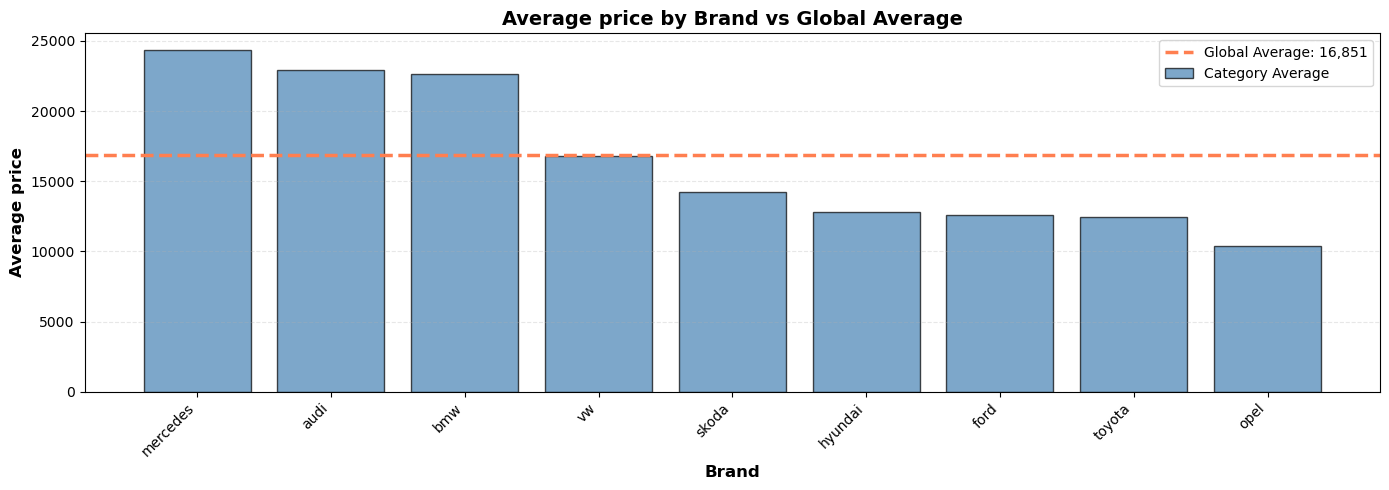

In [30]:
# Combine X_train and y_train into one DataFrame
df_train = X_train.copy()
df_train['price'] = y_train

# Call the function
plot_category_mean_vs_global_avg(
    df=df_train,
    cat_col='Brand',
    cont_col='price'
)

Mercedes, Audi and BMW are our premium brands, with only the 3 of them being above the average price. The cheapest cars are the opels on average.

This is the reason that we flagged Mercedes, Audi and BMW as our premium brands.

Univariate analysis for transmission column:


/Users/hajdumarcell/Documents/GitHub/ML_Nova_IMS_25-26/Functions/visualization.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X_train, x=col, palette='Set1', ax=ax[0])


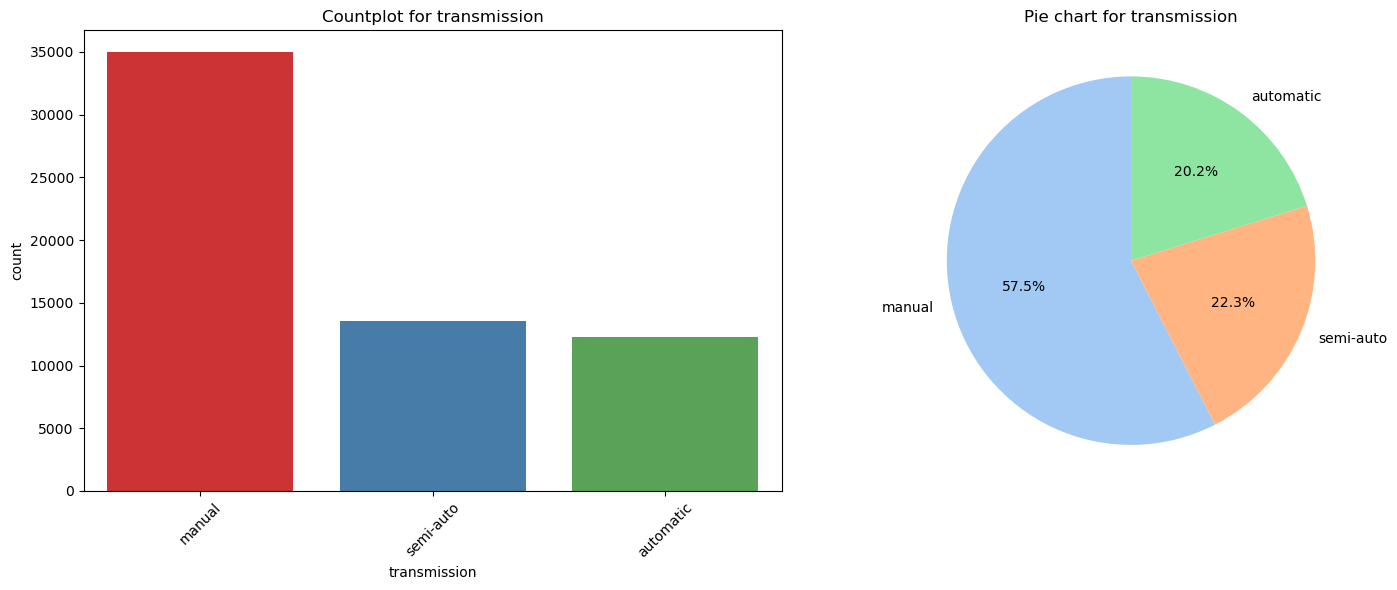

Univariate analysis for fuelType column:


/Users/hajdumarcell/Documents/GitHub/ML_Nova_IMS_25-26/Functions/visualization.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X_train, x=col, palette='Set1', ax=ax[0])


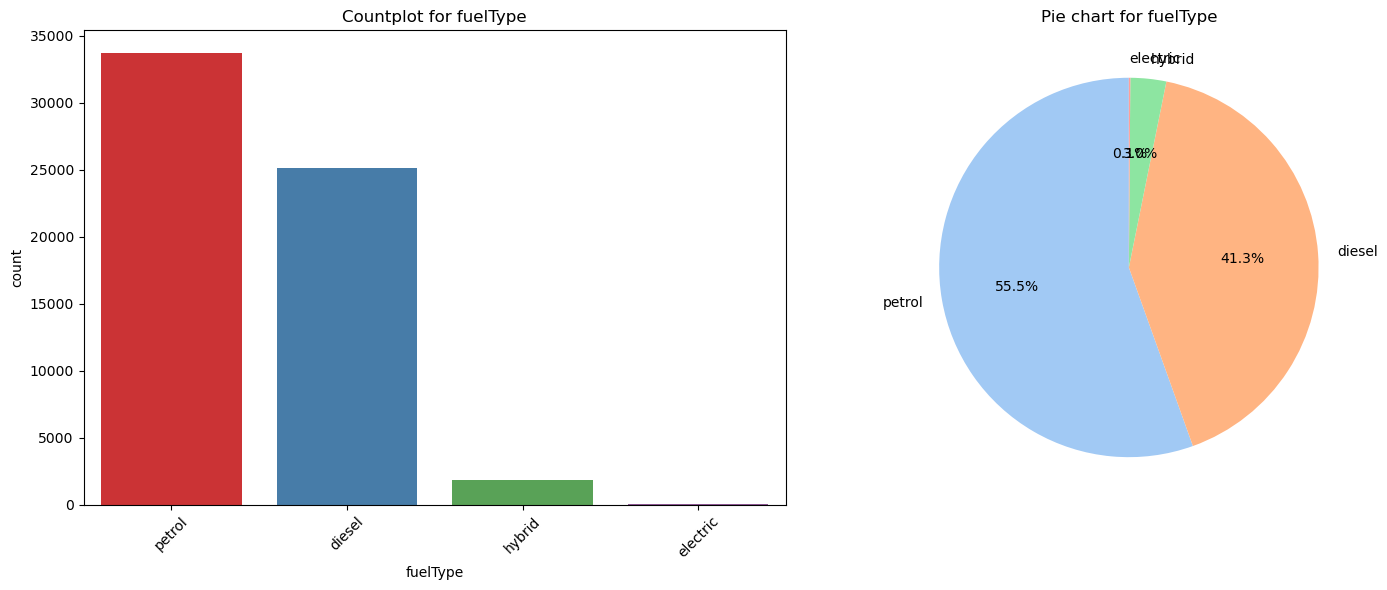

Univariate analysis for Brand column:


/Users/hajdumarcell/Documents/GitHub/ML_Nova_IMS_25-26/Functions/visualization.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X_train, x=col, palette='Set1', ax=ax[0])


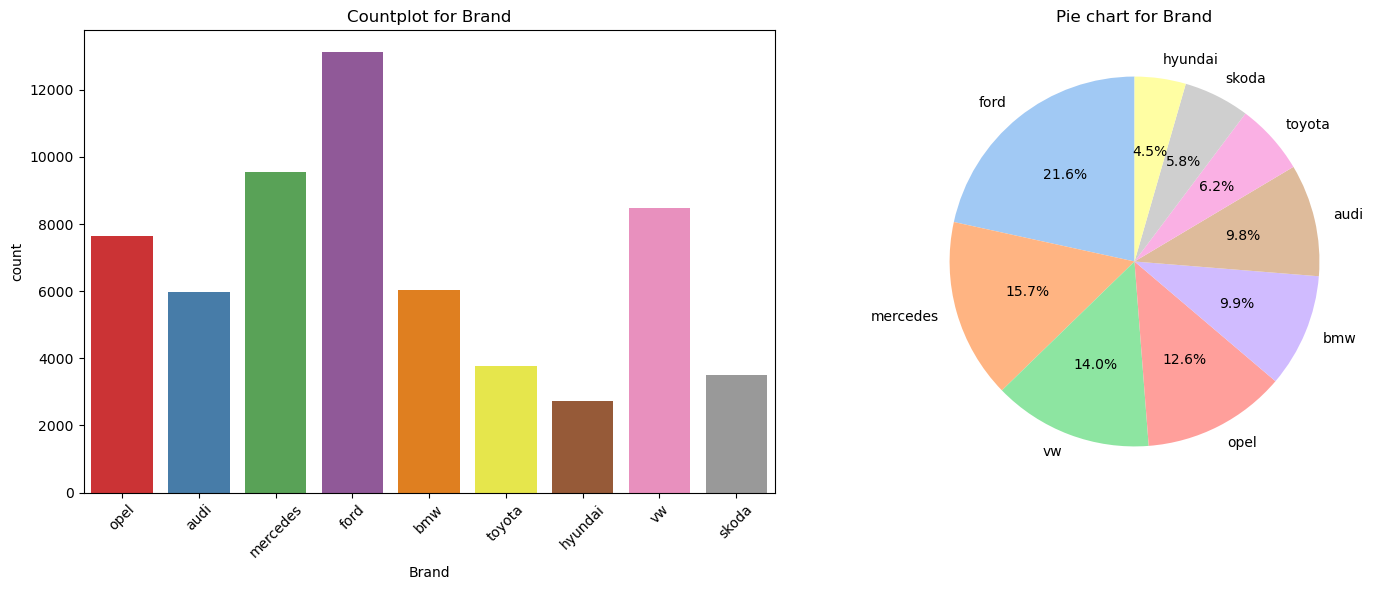

In [31]:
categorical_cols = ['transmission', 'fuelType','Brand']

for col in categorical_cols:
    print(f'Univariate analysis for {col} column:')
    univariate_analysis_cat(X_train, col)

The majority of our cars have manual transmissions. Semi-automatic and automatic transmissions appear with a similar frequency.

Most of our cars are running on either petrol or diesel.

We have the most cars from ford and the least from hyundai. We have more than 2000 observations for every car brand.

The dataset is not balanced based on our car brands, later in the modeling stage this will mean that some of our models will have to run on less observations. This also implies that there will be models that take longer to run than others.

Bivariate analysis for age


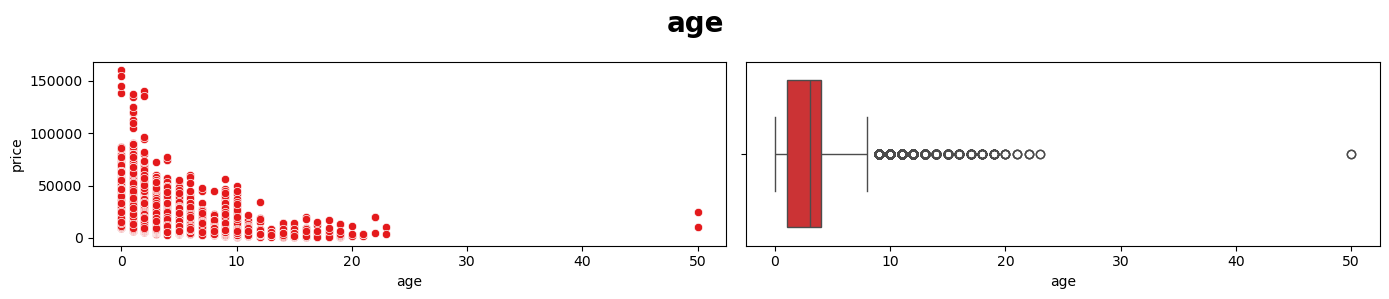

Bivariate analysis for mileage


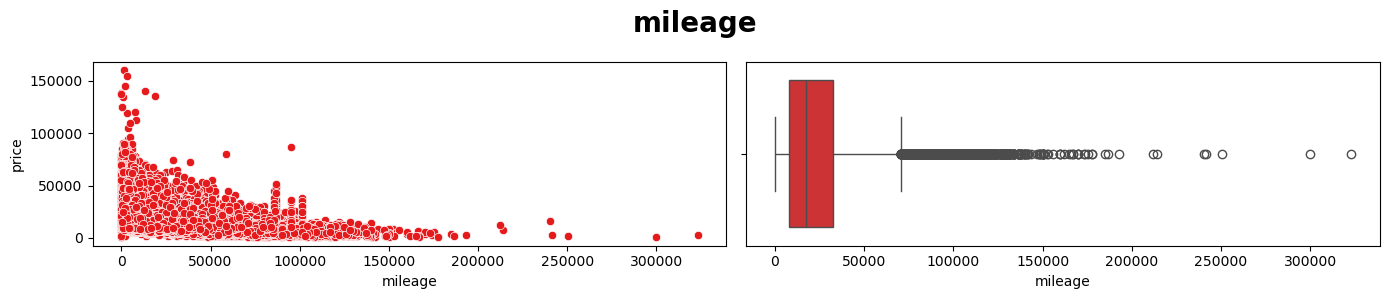

Bivariate analysis for tax


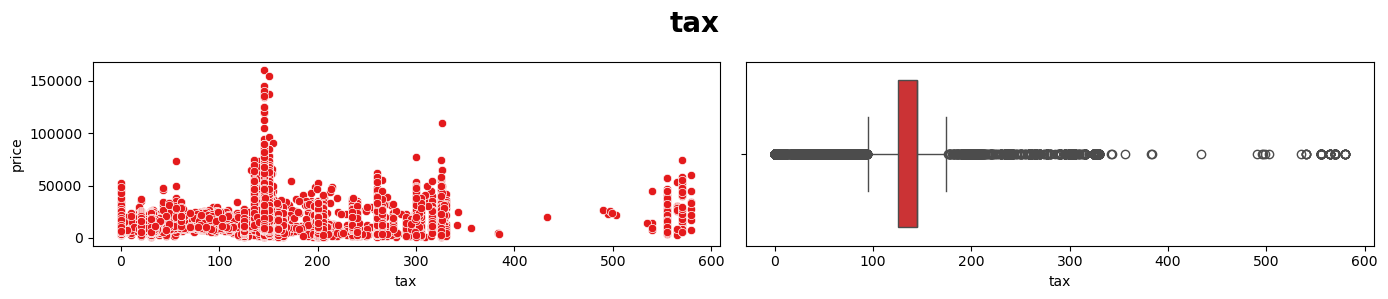

Bivariate analysis for mpg


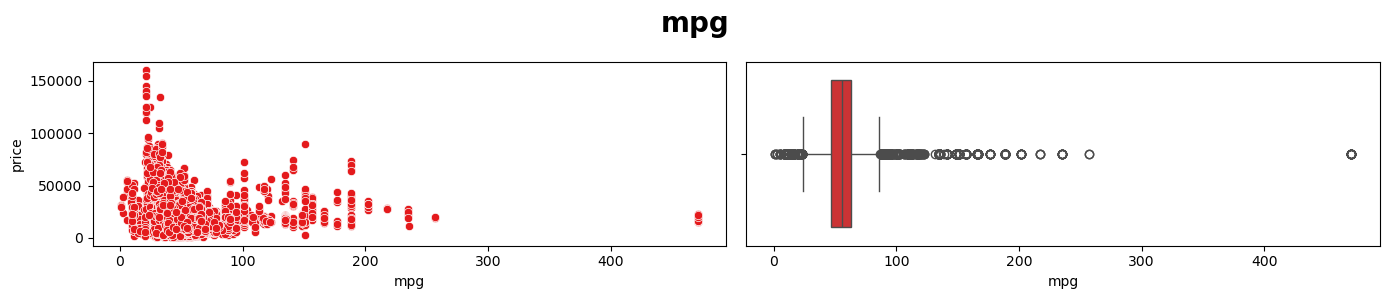

Bivariate analysis for engineSize


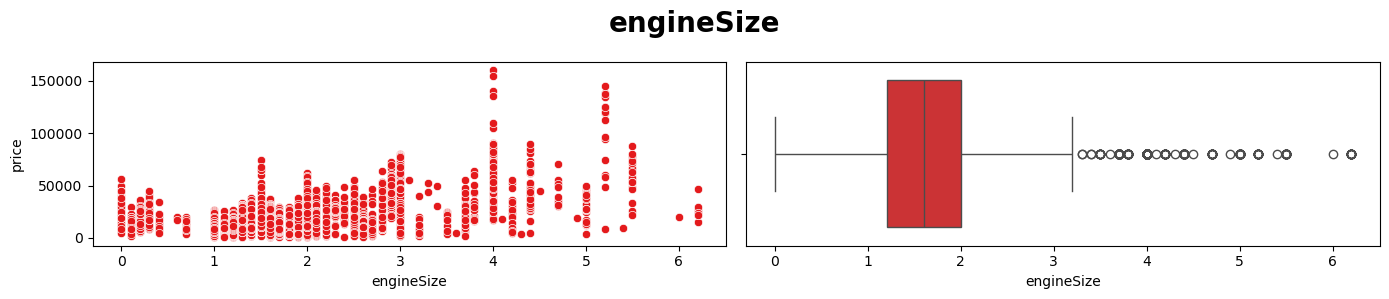

Bivariate analysis for previousOwners


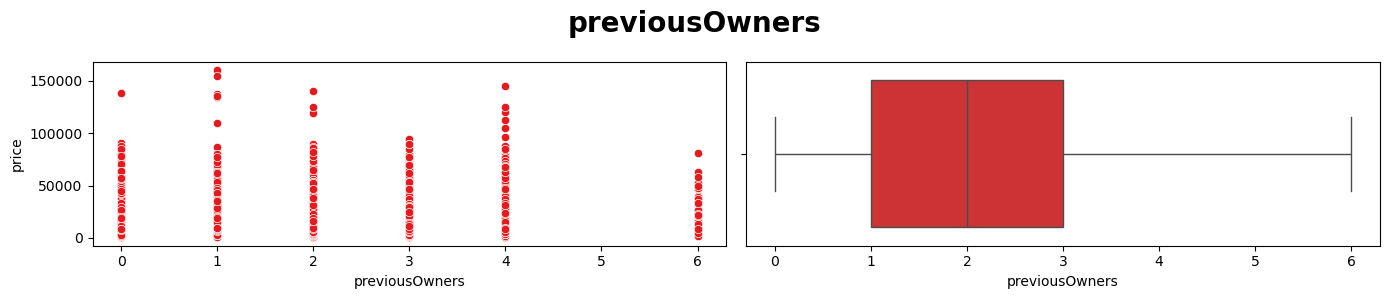

Bivariate analysis for mileage_per_year


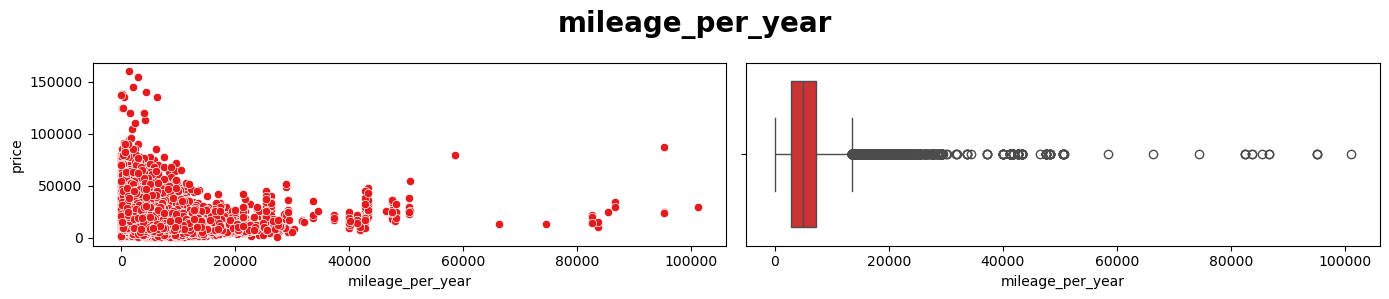

Bivariate analysis for efficiency_ratio


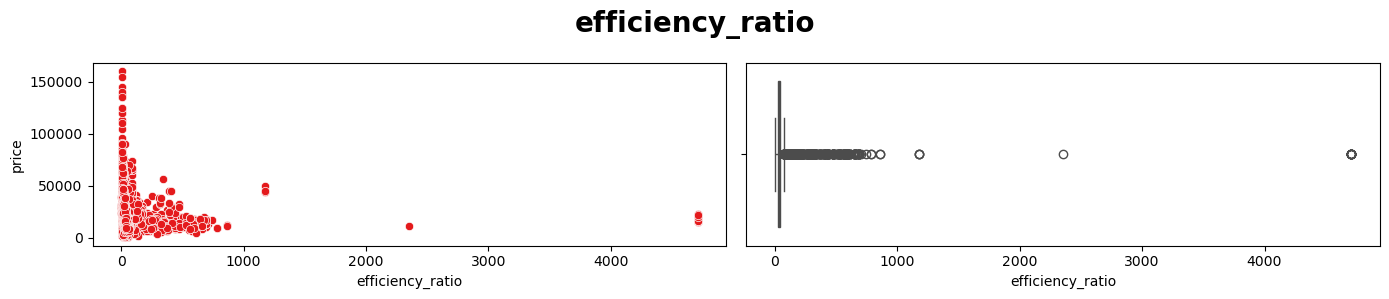

Bivariate analysis for age_mileage


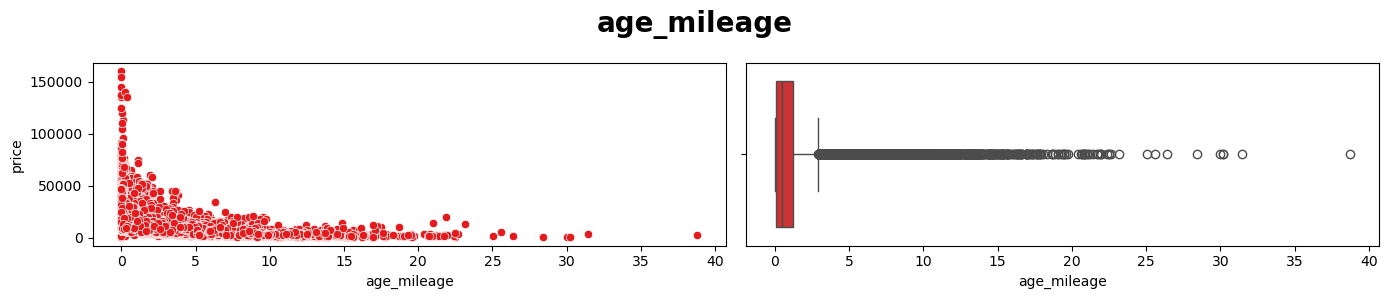

In [32]:
numerical_cols = [
    'age',
    'mileage',
    'tax',
    'mpg',
    'engineSize',
    'previousOwners',
    'mileage_per_year',
    'efficiency_ratio',
    'age_mileage',
]

for col in numerical_cols:
    print(f'Bivariate analysis for {col}')
    bivariate_analysis_num(X_train, y_train, x_col=col)

Most of our continuous features show some sort of linear or non-linear relationship with our target variable, there is most likely useful information in them for predicting the prices.

For the mpg, the efficieny ratio and the age columns, we still have a few outliers.

The age and mileage seem to have the clearest effect on the prices based on the visualizatons. Their relationships are not linear.

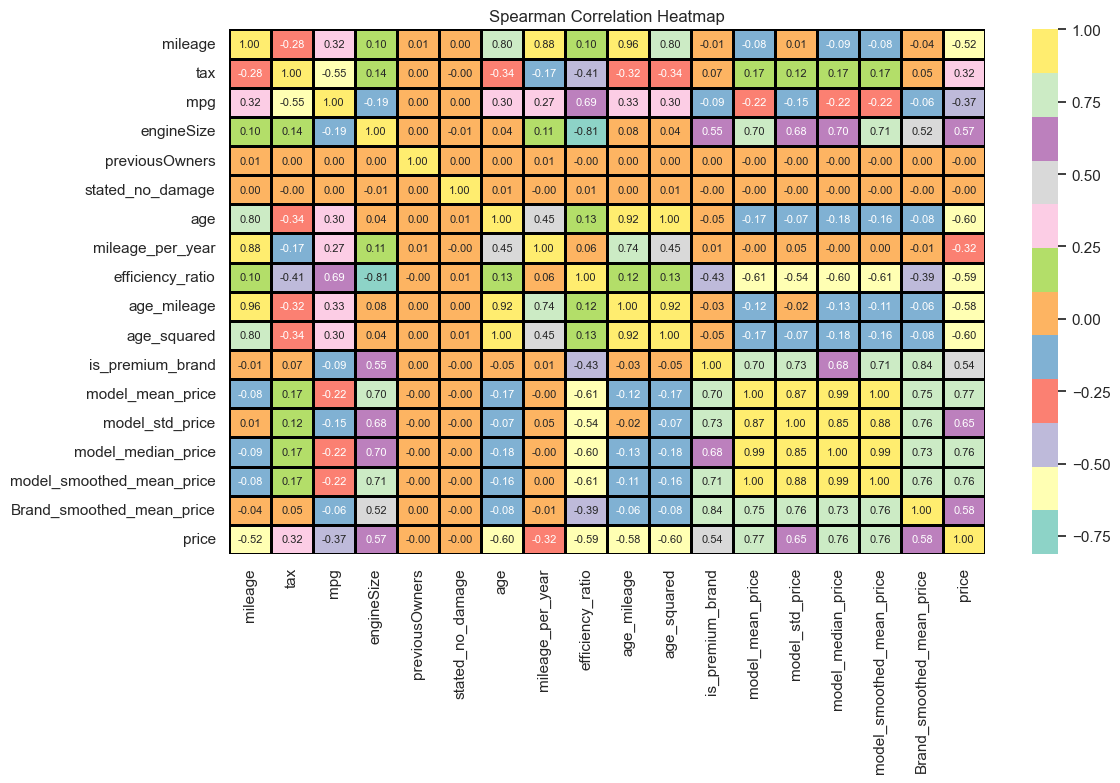

In [33]:
spearman_corr_heatmap(X_train, y_train)

There is correlation between our explanatory features and our target variable. Our features contain important information for predicting the car prices.

## Test of the models on the full dataset

In this section we analyze the performance of baseline implementations of five different
Scikit-learn models on our dataset. For each algorithm, we trained a separate instance for
each brand, guided by two main considerations.

First, training brand specific models allows for more precise predictions, since each model
can focus on the characteristics and pricing patterns that are unique to a given brand.

Second, this approach helps reduce training complexity and computational cost. Models such as
Neural Networks benefit from seeing less heterogeneous data, as they do not need to constantly
adapt their weights to highly variable instances. Similarly, for models like Random Forests or
Decision Trees, restricting the data to a single brand results in smaller and lighter models.

For all models, preprocessing is applied consistently as defined in the BrandModelTrainer class.
Categorical features are encoded using one hot encoding, while numerical features are scaled
using a Robust Scaler to mitigate the influence of outliers.


### Linear Regression

In [ ]:
LR = LinearRegression()
trainer = BrandModelTrainer(LR)

# fit
trainer.fit(X_train, y_train)

# performance overall
trainer.evaluate_train(X_train, y_train)
trainer.evaluate(X_val, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train, y_train)
trainer.evaluate_by_brand(X_val, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 3292.89
  MAE:  2094.98
  R²:   0.8822

Validation Set Performance (Overall):
  RMSE: 3295.09
  MAE:  2104.94
  R²:   0.8803

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7639 1667.469534 1194.725385 0.780960
    ford 13112 2009.436269 1435.387594 0.822525
   skoda  3504 2091.370902 1479.924346 0.883316
 hyundai  2720 2289.721447 1605.286555 0.853426
  toyota  3777 2389.443783 1505.592032 0.851764
      vw  8479 3082.307155 2085.516515 0.840345
     bmw  6037 4267.644404 2930.721126 0.858711
    audi  5970 4308.974066 2822.682022 0.863983
mercedes  9540 4934.950762 3345.451603 0.782167

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1769.633197 1245.949126 0.753199
   skoda  881

,Brand,N,RMSE,MAE,R²
7,opel,1907,1769.633197,1245.949126,0.753199
8,skoda,881,2038.349132,1464.690337,0.891076
1,ford,3278,2107.508744,1430.274785,0.804121
5,hyundai,688,2230.175135,1607.166388,0.854558
3,toyota,940,2753.211127,1630.191809,0.832422
0,vw,2125,2974.528525,2089.211924,0.853546
6,audi,1490,4231.641588,2841.985335,0.859982
2,bmw,1505,4264.700534,2920.888254,0.858348
4,mercedes,2381,4909.381742,3327.000987,0.779842


The results obtained with Linear Regression are poor; however, they still provide two useful
insights.

First, the difference between training and validation performance is around 10 MAE points.
This relatively small gap suggests that the train–validation split is well balanced.

Second, the overall low performance indicates that linear models are not well suited to the
current dataset. The relationships between features and the target variable appear to be
highly non linear, which limits the effectiveness of linear approaches.


### Decision Tree

In [ ]:
Tree = DecisionTreeRegressor(criterion="absolute_error")
trainer = BrandModelTrainer(Tree)

# fit
trainer.fit(X_train, y_train)

# performance overall
trainer.evaluate_train(X_train, y_train)
trainer.evaluate(X_val, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train, y_train)
trainer.evaluate_by_brand(X_val, y_val)        # Performance VALID

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 106.94
  MAE:  6.02
  R²:   0.9999

Validation Set Performance (Overall):
  RMSE: 2784.18
  MAE:  1628.37
  R²:   0.9146

Training Performance per Brand:
   Brand     N       RMSE       MAE       R²
  toyota  3777  36.493476  1.571353 0.999965
    ford 13112  60.259357  3.308344 0.999840
      vw  8479  71.265387  5.166175 0.999915
   skoda  3504  81.232575  3.905251 0.999824
    audi  5970  91.279664  4.120268 0.999939
    opel  7639 115.875492 10.035607 0.998942
     bmw  6037 124.888708  3.789631 0.999879
 hyundai  2720 143.842293 10.103309 0.999422
mercedes  9540 169.318722 11.266981 0.999744

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1536.520287 1034.332457 0.813938
    ford 3278 1875.383712 1142.477018 0.844893


,Brand,N,RMSE,MAE,R²
7,opel,1907,1536.520287,1034.332457,0.813938
1,ford,3278,1875.383712,1142.477018,0.844893
5,hyundai,688,1894.452972,1248.115742,0.895050
8,skoda,881,1895.542414,1285.103952,0.905804
3,toyota,940,2095.647573,1231.712345,0.902910
0,vw,2125,2534.604093,1589.792152,0.893663
6,audi,1490,3574.789169,2268.849709,0.900076
2,bmw,1505,3848.295271,2272.779208,0.884660
4,mercedes,2381,3942.665329,2392.851023,0.858009


As expected, the baseline Decision Tree model clearly overfits the training data. 

Nevertheless, its performance is noticeably better than that of the previous OLS model, 
demonstrating that non-linear models are able to capture complex dependencies in our dataset.

This confirms that the relationships between features and the target are non-linear, 
and using models capable of modeling such interactions can significantly improve predictions.


### KNR

In [ ]:
KNR = KNeighborsRegressor()
trainer = BrandModelTrainer(KNR)

# fit
trainer.fit(X_train, y_train)

# performance overall
trainer.evaluate_train(X_train, y_train)
trainer.evaluate(X_val, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train, y_train)
trainer.evaluate_by_brand(X_val, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 2055.03
  MAE:  1229.81
  R²:   0.9541

Validation Set Performance (Overall):
  RMSE: 2538.78
  MAE:  1544.85
  R²:   0.9290

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7639 1041.873539  692.743559 0.914486
    ford 13112 1276.176521  841.998759 0.928417
  toyota  3777 1343.820378  816.676752 0.953114
 hyundai  2720 1454.146644  929.255418 0.940883
   skoda  3504 1522.720121 1054.989509 0.938143
      vw  8479 1891.567380 1253.128911 0.939872
mercedes  9540 2834.765626 1803.210022 0.928122
     bmw  6037 2849.113105 1773.981051 0.937027
    audi  5970 2903.425868 1770.007414 0.938246

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1388.049109  910.195275 0.848159
    ford 3278

,Brand,N,RMSE,MAE,R²
7,opel,1907,1388.049109,910.195275,0.848159
1,ford,3278,1692.255887,1047.091889,0.873706
5,hyundai,688,1701.034199,1112.781108,0.915387
8,skoda,881,1788.054012,1262.927156,0.916184
3,toyota,940,1804.358125,1074.734770,0.928025
0,vw,2125,2197.724460,1518.245602,0.920051
6,audi,1490,3297.239929,2154.113157,0.914990
2,bmw,1505,3367.696603,2194.040884,0.911669
4,mercedes,2381,3749.687748,2385.313833,0.871569


The baseline K-Nearest Neighbors Regressor (KNR) achieved significantly better results than the
Decision Tree, both in terms of validation performance and reduced overfitting.

Notably, this is the first model that brings the MAE below 1000. The worst predictions are
observed for premium cars, likely because many models share similar specifications but have
substantially different prices.

This pattern persists throughout the analysis, suggesting that incorporating additional
information (such as design features or other latent characteristics) could further improve
model performance in this setting.


### Random Forest

In [ ]:
RF = RandomForestRegressor(random_state=69)
rf_trainer = BrandModelTrainer(RF)


rf_trainer.fit(X_train, y_train)


rf_trainer.evaluate_train(X_train, y_train)
rf_trainer.evaluate(X_val, y_val)

rf_trainer.evaluate_train_by_brand(X_train, y_train)
rf_trainer.evaluate_by_brand(X_val, y_val)



Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 768.50
  MAE:  465.35
  R²:   0.9936

Validation Set Performance (Overall):
  RMSE: 1991.67
  MAE:  1246.44
  R²:   0.9563

Training Performance per Brand:
   Brand     N        RMSE        MAE       R²
    opel  7639  451.816267 294.783729 0.983918
    ford 13112  515.244769 342.969274 0.988331
  toyota  3777  555.074664 334.001517 0.992001
 hyundai  2720  576.703584 365.859763 0.990702
   skoda  3504  605.418228 405.157220 0.990222
      vw  8479  699.304996 448.521420 0.991782
    audi  5970  993.968029 624.776343 0.992762
mercedes  9540 1046.321054 675.191906 0.990208
     bmw  6037 1077.809341 643.258729 0.990988

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1220.285546  810.680370 0.882645
 hyundai  688 1359.389123

,Brand,N,RMSE,MAE,R²
7,opel,1907,1220.285546,810.680370,0.882645
5,hyundai,688,1359.389123,935.539684,0.945962
3,toyota,940,1387.034547,925.126816,0.957468
1,ford,3278,1431.661586,908.092925,0.909608
8,skoda,881,1464.584153,1027.408651,0.943767
0,vw,2125,1774.577866,1201.369263,0.947874
2,bmw,1505,2558.573666,1688.515291,0.949015
6,audi,1490,2561.861275,1687.271384,0.948681
4,mercedes,2381,2856.159766,1843.932573,0.925485


The Random Forest model delivers substantially better results compared to the previous models.

While it still exhibits some overfitting, the degree is lower than that observed for the
Decision Tree. Importantly, the validation performance is the best achieved so far, indicating
strong generalization.

These results suggest that applying regularization to the Random Forest, such as limiting
tree depth could lead to significant further improvements.


### Neural Network

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp_deep = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),  
    activation='relu',
    solver='adam',
    alpha=0.001,  
    learning_rate_init=0.005,
    learning_rate='adaptive',
    max_iter=2000,
    batch_size=512,
    random_state=69,
    early_stopping=True,
    n_iter_no_change=30,  
    validation_fraction=0.15,
    verbose=True
)

mlp_trainer = BrandModelTrainer(mlp_deep)


mlp_trainer.fit(X_train, y_train)


mlp_trainer.evaluate_train(X_train, y_train)
mlp_trainer.evaluate(X_val, y_val)


mlp_trainer.evaluate_train_by_brand(X_train, y_train)
mlp_trainer.evaluate_by_brand(X_val, y_val)

Training models for 9 brands...

Iteration 1, loss = 59922001.14485014
Validation score: -7.629629
Iteration 2, loss = 59277330.21756189
Validation score: -7.390466
Iteration 3, loss = 55235891.28961706
Validation score: -6.195855
Iteration 4, loss = 41843526.84030516
Validation score: -3.124190
Iteration 5, loss = 20825835.10777947
Validation score: -0.369900
Iteration 6, loss = 9870217.72751484
Validation score: 0.314327
Iteration 7, loss = 5132896.46333721
Validation score: 0.430728
Iteration 8, loss = 3899618.06030843
Validation score: 0.534425
Iteration 9, loss = 3070879.40096343
Validation score: 0.590664
Iteration 10, loss = 2604072.70961327
Validation score: 0.631486
Iteration 11, loss = 2239697.60705751
Validation score: 0.660426
Iteration 12, loss = 1998247.86614648
Validation score: 0.683702
Iteration 13, loss = 1813210.29770647
Validation score: 0.701219
Iteration 14, loss = 1679024.13002857
Validation score: 0.712992
Iteration 15, loss = 1578346.28035486
Validation score: 

,Brand,N,RMSE,MAE,R²
7,opel,1907,1258.549088,868.686405,0.875170
5,hyundai,688,1443.649616,1024.769369,0.939055
3,toyota,940,1508.873735,969.428770,0.949668
1,ford,3278,1566.324594,1018.917211,0.891803
8,skoda,881,1808.851686,1205.999894,0.914223
0,vw,2125,1992.138869,1405.922721,0.934309
2,bmw,1505,2974.229628,1975.022063,0.931104
6,audi,1490,3150.777160,2095.822251,0.922375
4,mercedes,2381,3323.900929,2200.857971,0.899080


The results obtained with the Neural Network are somewhat disappointing. 

Although overfitting is minimal, the validation performance is significantly worse than that of
the Random Forest. 

The architecture and hyperparameter choices for the network were driven by the poor performance
of the Scikit-learn baseline and by design decisions made by Libero Biagi. The main objective
at this stage was to achieve convergence, which guided the selection of these hyperparameters.


### Performance

| Model              | RMSE    | MAE     | R²     |
|--------------------|---------|---------|--------|
| Linear Regression  | 3295.09 | 2104.94 | 0.8803 |
| Tree               | 2784.18 | 1628.37 | 0.9146 |
| KNR                | 2538.78 | 1544.85 | 0.9290 |
| RF                 | 1991.67 | 1246.44 | 0.9563 |
| NN                 | 2299.75 | 1447.74 | 0.9417 |


 

## Feature Selection

Feature selection is a critical step to make sure to reduce model complexity, remove redundant variables, improve model interpretability and performance. In this project, we implemented both filter and wrapper feature selection methods to ensure that the chosen features are both statisticaly relevant and effective for model performance.

## Feature selection - Filter Methods

This method uses statistical properties to score and select features independently of any model. It is ideal for the initial screening of features due to being computationally efficient and easy to interpret.
We applied the following techniques:

### 1. Variance 
Removes features with zero or near zero variance to eliminate features that are perfectly constant or quasi-constant.

### 2. Spearman correlation
Identifies and removes highly correlated features (|ρ|>0.85) to reduce redundancy and multicollinearity.

### 3. ANOVA F-Test
Asseses the statistical significance of the features with respect to the continuos target variable for categorical data.


The filter method quickly lets us narrow down the number of features while retaining variables which are the most informative. This step lays out a baseline for further feature selection and guarantees that only potentially relevant features are considered in the following model-based evaluation such the WRAPPER METHOD.


In [ ]:
df = X_train.join(y_train)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60778 entries, 0 to 60777
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   mileage                    60778 non-null  int32  
 1   tax                        60778 non-null  int32  
 2   mpg                        60778 non-null  float64
 3   engineSize                 60778 non-null  float64
 4   previousOwners             60778 non-null  int32  
 5   stated_no_damage           60778 non-null  float64
 6   Brand                      60778 non-null  object 
 7   transmission               60778 non-null  object 
 8   fuelType                   60778 non-null  object 
 9   age                        60778 non-null  int32  
 10  mileage_per_year           60778 non-null  float64
 11  efficiency_ratio           60778 non-null  float64
 12  age_mileage                60778 non-null  float64
 13  age_squared                60778 non-null  int32  


In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
y = df['price']

numerical_cols = df.select_dtypes(include=['int64', "int32",'float64']).columns

# Drop 'carID' and 'price'
num_cols = [col for col in numerical_cols 
            if "_transformed" not in col and col not in ['price', 'carID']]

print(num_cols)
print(categorical_cols)

['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'stated_no_damage', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 'is_premium_brand', 'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']
['Brand', 'transmission', 'fuelType']


In [ ]:
y = df["price"]

df = df.drop(columns=["price"])

In [ ]:

#X_train = df[num_cols]
#y_train = df['price']

# Filter method (Variance + Spearman + ANOVA)
# Define categorical and numerical columns first (if not already defined)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=['int64',"int32", 'float64']).columns.tolist()

# Filter method with all required parameters
selected_filter, X_train_filtered, filter_df = filter_method_selection(
    df, 
    y,
    categorical_cols=categorical_cols,  # Add this
    num_cols=num_cols,                  # Add this
    top_k=None, 
    var_threshold=0.01, 
    corr_threshold=0.85
)

# Print features selected
print("\nFeatures selected by Filter Method:")
for f in selected_filter:
    print(f)

# Display feature importance scores
print("\nTop 10 Features by ANOVA Score:")
print(filter_df.head(10))



FILTER METHOD (Variance + Spearman Correlation + ANOVA)
Removed 0 low-variance numeric features.
Removed 6 correlated numeric features (Spearman |corr| > 0.85).

Filter method selected 14 features

Features selected by Filter Method:
mileage
tax
mpg
engineSize
previousOwners
stated_no_damage
age
efficiency_ratio
is_premium_brand
model_mean_price
Brand_smoothed_mean_price
Brand
transmission
fuelType

Top 10 Features by ANOVA Score:
                      feature       ANOVA_F  ANOVA_p_value  ANOVA_norm  \
9            model_mean_price  34506.131607            0.0    1.000000   
3                  engineSize  22778.686348            0.0    0.660134   
10  Brand_smoothed_mean_price  18024.575683            0.0    0.522359   
8            is_premium_brand  15885.192765            0.0    0.460358   
6                         age  14625.725403            0.0    0.423859   
12               transmission  13297.120538            0.0    0.385355   
0                     mileage  10579.966751    

(Filter method tables) #### Variance and Spearman correlation results

| Numerical Predictor          | Conclusion |
| ------------------------- | ------------- | 
| mileage                   | Keep     |
| tax                       | Keep     |
| mpg                       | Keep     |
| engineSize                | Keep     |
| previousOwners            | Keep     |
| stated_no_damage          | Keep     |
| age                       | Keep     |
| mileage_per_year          | Discard  |
| efficiency_ratio          | Keep     |
| age_mileage               | Discard  |
| age_squared               | Discard  |
| is_premium_brand          | Keep     |
| model_mean_price          | Keep     |
| model_std_price           | Discard  |
| model_median_price        | Discard  |
| model_smoothed_mean_price | Discard  |
| Brand_smoothed_mean_price | Keep     |
------------------------------------------------------------------------------

#### ANOVA F- Test results 
| Categorical Predictor | Conclusion |
| ------------ | -------- |
| Brand        | Keep     |
| transmission | Keep     |
| fuelType     | Keep     |

After applying the Filter Method, a total of 14 features were selected. The categorical data were all kept by the ANOVA F-test while for the numerical data, the Filter method removed:

- mileage_per_year 
- age_mileage 
- age_squared
- model_std_price 
- model_median_price 
- model_smoothed_mean_price

## Test models on reduced DF

In [ ]:
X_train_filter = X_train[["mileage", "tax", "mpg", "engineSize", "previousOwners", "stated_no_damage" ,"age", "efficiency_ratio", 
                          "is_premium_brand", "model_mean_price", "Brand_smoothed_mean_price", "Brand" ,"transmission","fuelType"]]
X_train_filter

,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,age,efficiency_ratio,is_premium_brand,model_mean_price,Brand_smoothed_mean_price,Brand,transmission,fuelType
0,11899,125,51.4,1.4,2,1.0,4,34.266667,0,10507.578842,10419.530439,opel,manual,petrol
1,18500,145,48.9,1.4,4,1.0,2,32.600000,1,22898.738966,22868.301819,audi,semi-auto,petrol
2,10658,145,46.3,1.5,2,1.0,1,28.937500,1,23589.447727,24280.239606,mercedes,semi-auto,petrol
3,1500,145,43.5,0.0,4,1.0,0,435.000000,1,22528.871854,22868.301819,audi,manual,petrol
4,18495,100,64.7,2.1,4,1.0,3,29.409091,1,23589.447727,24280.239606,mercedes,automatic,diesel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60773,14867,150,55.4,1.4,3,1.0,2,36.933333,0,8328.251796,10419.530439,opel,manual,petrol
60774,20100,145,52.3,1.2,3,1.0,2,40.230769,0,12396.731646,12480.568926,toyota,manual,petrol
60775,10498,145,68.9,1.0,0,1.0,2,62.636364,0,7999.734222,12480.568926,toyota,manual,petrol
60776,17502,145,40.4,2.0,4,1.0,3,19.238095,1,30314.780335,22868.301819,audi,semi-auto,petrol


In [ ]:
X_val_filter = X_val[["mileage", "tax", "mpg", "engineSize", "previousOwners", "stated_no_damage" ,"age", "efficiency_ratio", 
                          "is_premium_brand", "model_mean_price", "Brand_smoothed_mean_price", "Brand" ,"transmission","fuelType"]]

X_val_filter

,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,age,efficiency_ratio,is_premium_brand,model_mean_price,Brand_smoothed_mean_price,Brand,transmission,fuelType
0,14774,145,53.3,2.0,0,1.0,1,25.380952,0,17076.879837,16832.279028,vw,manual,diesel
1,16375,150,47.9,1.6,4,1.0,4,28.176471,0,10239.929954,12586.804805,ford,manual,petrol
2,32746,265,37.2,3.0,3,0.0,4,12.000000,1,19668.441349,22615.825636,bmw,semi-auto,petrol
3,10164,145,68.9,1.5,3,1.0,1,43.062500,1,15831.478771,22615.825636,bmw,automatic,diesel
4,11407,145,80.7,1.5,2,1.0,1,50.437500,0,13391.940062,12586.804805,ford,manual,diesel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15190,10766,20,51.4,1.4,2,1.0,1,34.266667,0,10507.578842,10419.530439,opel,manual,petrol
15191,5000,145,48.7,2.0,1,1.0,0,23.190476,0,17076.879837,16832.279028,vw,semi-auto,diesel
15192,28056,145,60.1,2.0,0,1.0,3,28.619048,0,15827.996432,12586.804805,ford,manual,diesel
15193,25169,145,56.5,1.0,4,1.0,2,51.363636,0,10239.929954,12586.804805,ford,manual,petrol


### Linear Regression

In [ ]:
LR = LinearRegression()
trainer = BrandModelTrainer(LR)

# fit
trainer.fit(X_train_filter, y_train)

# performance overall
trainer.evaluate_train(X_train_filter, y_train)
trainer.evaluate(X_val_filter, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train_filter, y_train)
trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 3570.10
  MAE:  2228.07
  R²:   0.8615

Validation Set Performance (Overall):
  RMSE: 3529.89
  MAE:  2243.50
  R²:   0.8627

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7639 1840.060280 1257.662132 0.733270
    ford 13112 2192.400260 1579.694936 0.788735
   skoda  3504 2237.049753 1540.528780 0.866494
  toyota  3777 2467.730237 1509.424865 0.841891
 hyundai  2720 2507.292883 1715.141804 0.824247
      vw  8479 3220.851829 2126.645357 0.825670
    audi  5970 4622.752091 2999.433482 0.843452
     bmw  6037 4835.730387 3318.512662 0.818592
mercedes  9540 5333.915226 3496.929781 0.745521

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1902.471598 1318.476159 0.714756
   skoda  881

,Brand,N,RMSE,MAE,R²
7,opel,1907,1902.471598,1318.476159,0.714756
8,skoda,881,2225.044772,1533.135127,0.870210
1,ford,3278,2303.208843,1570.878464,0.766053
5,hyundai,688,2401.532014,1661.654052,0.831349
3,toyota,940,2868.238572,1637.637230,0.818127
0,vw,2125,3126.797650,2168.700905,0.838168
6,audi,1490,4440.355219,2994.812530,0.845829
2,bmw,1505,4909.252626,3351.007326,0.812295
4,mercedes,2381,5125.540766,3477.084819,0.760028


### Single tree

In [ ]:
Tree = DecisionTreeRegressor(criterion="absolute_error")
trainer = BrandModelTrainer(Tree)

# fit
trainer.fit(X_train_filter, y_train)

# performance overall
trainer.evaluate_train(X_train_filter, y_train)
trainer.evaluate(X_val_filter, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train_filter, y_train)
trainer.evaluate_by_brand(X_val_filter, y_val)        # Performance VALID

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 106.20
  MAE:  5.98
  R²:   0.9999

Validation Set Performance (Overall):
  RMSE: 2888.87
  MAE:  1650.53
  R²:   0.9080

Training Performance per Brand:
   Brand     N       RMSE       MAE       R²
  toyota  3777  36.493476  1.571353 0.999965
    ford 13112  60.259357  3.308344 0.999840
      vw  8479  71.265387  5.166175 0.999915
   skoda  3504  81.232575  3.905251 0.999824
    audi  5970  91.279664  4.120268 0.999939
    opel  7639 119.280808 10.625475 0.998879
 hyundai  2720 122.213745  7.607721 0.999582
     bmw  6037 124.888708  3.789631 0.999879
mercedes  9540 169.318722 11.266981 0.999744

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1570.465161 1011.563037 0.805627
 hyundai  688 1737.266222 1187.331121 0.911744


,Brand,N,RMSE,MAE,R²
7,opel,1907,1570.465161,1011.563037,0.805627
5,hyundai,688,1737.266222,1187.331121,0.911744
1,ford,3278,1903.812368,1171.349031,0.840155
8,skoda,881,1981.147633,1339.722517,0.897104
3,toyota,940,2437.360621,1279.322876,0.868666
0,vw,2125,3125.673380,1676.439177,0.838284
6,audi,1490,3314.182538,2159.628166,0.914115
2,bmw,1505,3696.518117,2295.192022,0.893578
4,mercedes,2381,4170.694210,2468.211533,0.841110


In [ ]:
KNR = KNeighborsRegressor()
trainer = BrandModelTrainer(KNR)

# fit
trainer.fit(X_train_filter, y_train)

# performance overall
trainer.evaluate_train(X_train_filter, y_train)
trainer.evaluate(X_val_filter, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train_filter, y_train)
trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 2098.20
  MAE:  1276.77
  R²:   0.9522

Validation Set Performance (Overall):
  RMSE: 2630.18
  MAE:  1615.69
  R²:   0.9237

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7639 1064.065309  706.171336 0.910804
    ford 13112 1266.008475  853.003879 0.929553
  toyota  3777 1307.223450  830.778069 0.955633
 hyundai  2720 1528.371309  986.472157 0.934694
   skoda  3504 1537.986957 1105.625457 0.936896
      vw  8479 1886.636398 1274.261893 0.940185
mercedes  9540 2833.213043 1856.996880 0.928201
    audi  5970 2950.124889 1842.854217 0.936243
     bmw  6037 3102.066545 1955.203308 0.925349

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1456.369048  958.195886 0.832844
    ford 3278

,Brand,N,RMSE,MAE,R²
7,opel,1907,1456.369048,958.195886,0.832844
1,ford,3278,1653.807009,1053.387411,0.879380
3,toyota,940,1794.908828,1088.782615,0.928777
5,hyundai,688,1822.168282,1235.461479,0.902907
8,skoda,881,1829.160220,1338.332831,0.912286
0,vw,2125,2347.457779,1609.095081,0.908786
6,audi,1490,3388.417795,2284.577267,0.910224
2,bmw,1505,3667.421133,2410.787342,0.895247
4,mercedes,2381,3822.325546,2421.701867,0.866545


In [ ]:
RF = RandomForestRegressor(random_state=69)
rf_trainer = BrandModelTrainer(RF)


rf_trainer.fit(X_train_filter, y_train)


rf_trainer.evaluate_train(X_train_filter, y_train)
rf_trainer.evaluate(X_val_filter, y_val)

rf_trainer.evaluate_train_by_brand(X_train_filter, y_train)
rf_trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 785.90
  MAE:  468.56
  R²:   0.9933

Validation Set Performance (Overall):
  RMSE: 2025.20
  MAE:  1258.21
  R²:   0.9548

Training Performance per Brand:
   Brand     N        RMSE        MAE       R²
    opel  7639  451.214756 296.000806 0.983961
    ford 13112  514.081272 344.235861 0.988384
  toyota  3777  556.556758 336.448527 0.991958
 hyundai  2720  577.133705 367.459987 0.990688
   skoda  3504  613.925215 405.522810 0.989945
      vw  8479  707.233177 452.150723 0.991595
    audi  5970  987.956255 624.225526 0.992850
     bmw  6037 1071.340804 645.906182 0.991096
mercedes  9540 1127.362785 686.831270 0.988632

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1224.021517  810.504776 0.881925
 hyundai  688 1362.149553

,Brand,N,RMSE,MAE,R²
7,opel,1907,1224.021517,810.504776,0.881925
5,hyundai,688,1362.149553,923.393618,0.945742
3,toyota,940,1425.518481,935.318314,0.955076
1,ford,3278,1459.582080,918.884518,0.906048
8,skoda,881,1474.669743,1043.310293,0.942990
0,vw,2125,1783.897763,1209.853740,0.947325
6,audi,1490,2556.514509,1683.716134,0.948895
2,bmw,1505,2641.023399,1689.789445,0.945676
4,mercedes,2381,2925.662330,1891.800705,0.921814


### Neural Network

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp_deep = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),  
    activation='relu',
    solver='adam',
    alpha=0.001,  
    learning_rate_init=0.005,
    learning_rate='adaptive',
    max_iter=2000,
    batch_size=512,
    random_state=69,
    early_stopping=True,
    n_iter_no_change=30,  
    validation_fraction=0.15,
    verbose=True
)

mlp_trainer = BrandModelTrainer(mlp_deep)


mlp_trainer.fit(X_train_filter, y_train)


mlp_trainer.evaluate_train(X_train_filter, y_train)
mlp_trainer.evaluate(X_val_filter, y_val)


mlp_trainer.evaluate_train_by_brand(X_train_filter, y_train)
mlp_trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

Iteration 1, loss = 60066409.33365963
Validation score: -8.315767
Iteration 2, loss = 59254451.77543236
Validation score: -7.994818
Iteration 3, loss = 54725098.18504441
Validation score: -6.568967
Iteration 4, loss = 40126545.27608380
Validation score: -3.033254
Iteration 5, loss = 16523543.91852779
Validation score: -0.166745
Iteration 6, loss = 7357123.61943739
Validation score: 0.263986
Iteration 7, loss = 4294596.47574004
Validation score: 0.415924
Iteration 8, loss = 3298037.92544643
Validation score: 0.532557
Iteration 9, loss = 2680716.62580328
Validation score: 0.587788
Iteration 10, loss = 2358772.10058031
Validation score: 0.622015
Iteration 11, loss = 2044927.34472994
Validation score: 0.642709
Iteration 12, loss = 1879136.11622514
Validation score: 0.658311
Iteration 13, loss = 1769584.33763550
Validation score: 0.667238
Iteration 14, loss = 1695593.15658667
Validation score: 0.673567
Iteration 15, loss = 1646701.00973635
Validation score: 

,Brand,N,RMSE,MAE,R²
7,opel,1907,1424.118767,918.491836,0.840165
5,hyundai,688,1493.849314,1066.806887,0.934743
1,ford,3278,1564.678187,1008.898866,0.892031
8,skoda,881,1770.631097,1223.020336,0.917810
3,toyota,940,1773.196593,1032.296165,0.930489
0,vw,2125,2147.081830,1531.339990,0.923693
6,audi,1490,3214.564209,2136.465212,0.919200
2,bmw,1505,3333.090936,2283.533060,0.913475
4,mercedes,2381,3457.100053,2323.957847,0.890830


### Results

Performance on the full dataset
| Model              | RMSE    | MAE     | R²     |
|--------------------|---------|---------|--------|
| Linear Regression  | 3295.09 | 2104.94 | 0.8803 |
| Tree               | 2784.18 | 1628.37 | 0.9146 |
| KNR                | 2538.78 | 1544.85 | 0.9290 |
| RF                 | 1991.67 | 1246.44 | 0.9563 |
| NN                 | 2299.75 | 1447.74 | 0.9417 |




Performance on the reduced dataset
| Model              | RMSE    | MAE     | R²     |
|--------------------|---------|---------|--------|
| Linear Regression  | 3529.89 | 2243.50 | 0.8627 |
| Tree               | 2888.87 | 1650.53 | 0.9080 |
| KNR                | 2630.18 | 1615.69 | 0.9237 |
| RF                 | 2025.20 | 1258.21 | 0.9548 |
| NN                 | 2427.16 | 1529.98 | 0.9351 |




## Feature Selection - Wrapper Method

Wrapper methods evaluate features based on how they affect the model’s performance, which makes them more accurate at finding important features  than filter methods alone. 
We chose RFE with Random Forest because it can handle unscaled and non-linear data and reliably identify the most predictive subset of features. RFE ensures that we’re keeping only those features that contribute the most to the model’s performance.

In [ ]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(num_cols)

['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'stated_no_damage', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 'is_premium_brand', 'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']


In [ ]:
nof, best_score, selected_rfe_features, train_scores, val_scores = rfe(
    X_train, X_val, y_train, y_val, num_cols
)

Using 17 numeric columns for RFE:
['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'stated_no_damage', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 'is_premium_brand', 'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']

Optimum number of features: 14
Best validation MAE: 1294.8360
Selected features:
['mileage', 'tax', 'mpg', 'engineSize', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']


(Wrapper method) #### WRAPPER METHOD (RFE) Results

| Predictor | Conclusion |
| --------- | ------- |
| mileage                   | Keep |         
| tax                       | Keep |         
| mpg                       | Keep |        
| engineSize                | Keep |
| previousOwners            | Discard | 
| stated_no_damage          | Discard |  
| age                       | Keep   |      
| mileage_per_year          | Keep  |   
| efficiency_ratio          | Keep   |
| age_mileage               | Keep  |
| age_squared               | Keep   | 
| is_premium_brand          | Discard | 
| model_mean_price          | Keep   |
| model_std_price           | Keep   |
| model_median_price        | Keep  |
| model_smoothed_mean_price | Keep  |
| Brand_smoothed_mean_price | Keep   | 

Although the feature selection using the filter method was useful as an initial step to see statistical relevance of the predictors, Filter method could be less effective than other Feature selection methods that are based on models. For this reason, we decided to apply a wrapper method, a RFE with Random Forest and MAE as metric.
This method removes only 3 numerical features:

- previouOwners
- stated_no_damage
- is_premium_brand

Our feature selection strategy using a wrapper method was applied only to the numerical features,
for several practical and methodological reasons.

Categorical variables require encoding, and applying feature selection after encoding would likely
lead the model to select only subsets of the encoded categories. This could result in inconsistent
and hard to interpret feature sets, such as selecting only some fuel types or transmission modes.
To avoid these issues, categorical features were kept intact.

Additionally, the brand variable is used to train separate brand-specific models, so it must be
retained by design and cannot be subjected to feature selection.

Finally, including the encoded categorical features in the wrapper method would have significantly
increased computational cost, making the recursive feature elimination process considerably slower
without a clear expected benefit.


In [34]:
X_train_rfed = X_train[["Brand", "transmission", "fuelType", 'mileage', 'tax', 'mpg', 'engineSize', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 
                        'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']]
X_train_rfed

,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
0,opel,manual,petrol,11899,126,51.4,1.4,4,2379.800000,34.266667,0.47596,16,10497.326191,3126.611449,10291.0,10580.427829,10418.799066
1,audi,semi-auto,petrol,18500,145,48.3,1.4,2,6166.666667,32.200000,0.37000,4,22898.637626,7109.526770,20994.5,22749.667398,22867.652524
2,mercedes,semi-auto,petrol,10658,145,46.3,1.5,1,5329.000000,28.937500,0.10658,1,23602.659498,8501.399122,22995.0,23570.794406,24279.101733
3,audi,manual,petrol,1500,145,43.5,0.0,0,1500.000000,435.000000,0.00000,0,22702.006912,5179.534782,21995.0,22444.228915,22867.652524
4,mercedes,automatic,diesel,18495,105,63.1,2.1,3,4623.750000,28.681818,0.55485,9,23602.659498,8501.399122,22995.0,23570.794406,24279.101733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60773,opel,manual,petrol,14867,150,55.4,1.4,2,4955.666667,36.933333,0.29734,4,8294.790077,2534.945078,7999.0,8385.807697,10418.799066
60774,toyota,manual,petrol,20100,145,52.3,1.2,2,6700.000000,40.230769,0.40200,4,12488.508685,3308.095666,12795.0,12694.746874,12475.380527
60775,toyota,manual,petrol,10498,145,68.9,1.0,2,3499.333333,62.636364,0.20996,4,8021.135472,1847.053009,7989.5,8175.764385,12475.380527
60776,audi,semi-auto,petrol,17502,145,40.4,2.0,3,4375.500000,19.238095,0.52506,9,30289.237996,9395.222901,31000.0,29750.609073,22867.652524


In [35]:
X_val_rfed = X_val[["Brand", "transmission", "fuelType", 'mileage', 'tax', 'mpg', 'engineSize', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 
                        'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']]
X_val_rfed

,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
0,vw,manual,diesel,14774,145,53.3,2.0,1,7387.000000,25.380952,0.14774,1,16791.440816,7569.382483,15270.0,16793.754760,16832.209726
1,ford,manual,petrol,16375,150,47.9,1.6,4,3275.000000,28.176471,0.65500,16,10249.547806,2931.782347,9997.5,10285.598590,12584.746172
2,bmw,semi-auto,petrol,32746,265,37.2,3.0,4,6549.200000,12.000000,1.30984,16,19655.452416,5341.737052,19995.0,19575.651391,22615.667356
3,bmw,automatic,diesel,10164,145,68.9,1.5,1,5082.000000,43.062500,0.10164,1,15836.032550,6078.925536,14599.5,15854.050557,22615.667356
4,ford,manual,diesel,11407,145,80.7,1.5,1,5703.500000,50.437500,0.11407,1,13403.072819,4624.054554,13000.0,13415.338870,12584.746172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15190,opel,manual,petrol,10766,20,51.4,1.4,1,5383.000000,34.266667,0.10766,1,10497.326191,3126.611449,10291.0,10580.427829,10418.799066
15191,vw,semi-auto,diesel,5000,145,48.7,2.0,0,5000.000000,23.190476,0.00000,0,16791.440816,7569.382483,15270.0,16793.754760,16832.209726
15192,ford,manual,diesel,28056,145,60.1,2.0,3,7014.000000,28.619048,0.84168,9,15804.279248,3702.538325,15800.0,15821.359528,12584.746172
15193,ford,manual,petrol,25169,145,56.5,1.0,2,8389.666667,51.363636,0.50338,4,10249.547806,2931.782347,9997.5,10285.598590,12584.746172


In [ ]:
RF = RandomForestRegressor(random_state=69)
rf_trainer = BrandModelTrainer(RF)


rf_trainer.fit(X_train_rfed, y_train)


rf_trainer.evaluate_train(X_train_rfed, y_train)
rf_trainer.evaluate(X_val_rfed, y_val)

rf_trainer.evaluate_train_by_brand(X_train_rfed, y_train)
rf_trainer.evaluate_by_brand(X_val_rfed, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 778.52
  MAE:  469.55
  R²:   0.9934

Validation Set Performance (Overall):
  RMSE: 1989.92
  MAE:  1245.95
  R²:   0.9564

Training Performance per Brand:
   Brand     N        RMSE        MAE       R²
    opel  7639  466.263994 303.836043 0.982873
    ford 13112  520.226256 344.980738 0.988105
  toyota  3777  561.175332 338.314063 0.991824
 hyundai  2720  588.609256 372.275767 0.990314
   skoda  3504  610.274535 407.135711 0.990064
      vw  8479  721.324548 457.847922 0.991256
    audi  5970 1004.233569 632.142731 0.992612
mercedes  9540 1050.500909 672.928257 0.990129
     bmw  6037 1094.426982 646.209165 0.990708

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1232.654132  815.780246 0.880254
 hyundai  688 1382.947706

,Brand,N,RMSE,MAE,R²
7,opel,1907,1232.654132,815.780246,0.880254
5,hyundai,688,1382.947706,946.775414,0.944073
3,toyota,940,1396.447584,938.245311,0.956889
1,ford,3278,1443.439109,914.419878,0.908115
8,skoda,881,1452.451483,1016.089932,0.944694
0,vw,2125,1767.862657,1202.161278,0.948268
2,bmw,1505,2525.267716,1665.576228,0.950334
6,audi,1490,2565.602576,1685.235865,0.948531
4,mercedes,2381,2853.534595,1838.853915,0.925622


Final Results

Performance on the full dataset
| Model              | RMSE    | MAE     | R²     |
|--------------------|---------|---------|--------|
| Linear Regression  | 3295.09 | 2104.94 | 0.8803 |
| Tree               | 2784.18 | 1628.37 | 0.9146 |
| KNR                | 2538.78 | 1544.85 | 0.9290 |
| RF                 | 1991.67 | 1246.44 | 0.9563 |
| NN                 | 2299.75 | 1447.74 | 0.9417 |




Performance on the reduced dataset
| Model              | RMSE    | MAE     | R²     |
|--------------------|---------|---------|--------|
| Linear Regression  | 3529.89 | 2243.50 | 0.8627 |
| Tree               | 2888.87 | 1650.53 | 0.9080 |
| KNR                | 2630.18 | 1615.69 | 0.9237 |
| RF                 | 2025.20 | 1258.21 | 0.9548 |
| NN                 | 2427.16 | 1529.98 | 0.9351 |





Random Forest on the rfed dataset

|*Model*| *RMSE*| *MAE* | *R²*|
|----|----|----|----|
|RF| 1989.92| 1245.95 | 0.9564|


The results are consistent with those obtained using the full dataset, indicating that no
significant information was lost through feature selection.

At the same time, the reduction in the number of features leads to faster training, which is
particularly beneficial for the subsequent hyperparameter tuning phase.


## Hyperparam tuning

As anticipated, we decided to continue the analysis using only a Random Forest model and to focus
on identifying the best set of hyperparameters.

Following the approach suggested during class, we employed a random search strategy, defining
a grid over the following parameters:

- Number of estimators  
- Maximum depth  
- Minimum samples required to split a node  
- Minimum samples required at a leaf  
- Maximum number of features considered at each split  
- Minimum impurity decrease  
- Maximum number of samples  
- Split criterion  

The following settings were kept fixed throughout the search:

- Bootstrap  
- Random state  
- Number of cores  

We adopted a holdout validation strategy, consistent with the rest of the project. In total, we
evaluated 120 hyperparameter combinations, allowing us to explore a sufficiently broad search
space while keeping the computational cost manageable.


In [ ]:
base_estimator = RandomForestRegressor(random_state=69, n_jobs=-1)
trainer = BrandModelTrainer(base_estimator)

param_space_rf_expanded = {
    "n_estimators": [500, 800, 1200, 1600, 2000], 

    "max_depth": [10, 15, 20, 25, 30],

    "min_samples_split": [3, 5, 8, 15], 
   
    "min_samples_leaf": [2, 4, 8, 12],
    
    "max_features": [0.2, 0.4, 0.6, 0.7], 
    
    "min_impurity_decrease": [0.0, 1e-4, 1e-3, 1e-2], 
    
    "max_samples": [0.6, 0.8, None], 
    
    "criterion": ["squared_error", "friedman_mse"],
    
    "bootstrap": [True],
    "random_state": [69],
    "n_jobs": [-1]
}

search = HoldoutRandomSearch(
    trainer_class=trainer,
    param_space=param_space_rf_expanded,
    n_iter=120  
)

best_trainer, best_params, best_rmse = search.run(X_train_rfed, y_train, X_val_rfed, y_val)


Running random search (120 iterations)...
Optimizing for: MAE


[1/120] Testing params:
{'n_estimators': 800, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.2, 'min_impurity_decrease': 0.0, 'max_samples': None, 'criterion': 'squared_error', 'bootstrap': True, 'random_state': 69, 'n_jobs': -1}
Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Validation Set Performance (Overall):
  RMSE: 1980.02
  MAE:  1226.07
  R²:   0.9568
New best overall model (MAE: 1226.07)

Progress: 1/120 | Elapsed: 94.9s | ETA: ~11294.6s

[2/120] Testing params:
{'n_estimators': 2000, 'max_depth': 25, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 0.6, 'min_impurity_decrease': 0.001, 'max_samples': None, 'criterion': 'friedman_mse', 'bootstrap': True, 'random_state': 69, 'n_jobs': -1}
Training models for 9 brands...

  ✓ opel done.
  ✓ a

As defined in the HoldOutRandomSearch class, a report is produced for each brand specific
model. This allows us to select the best hyperparameter configuration independently for every
brand, while also identifying the configuration that performs best on average, which can later
be used to train a general model.

From the reported results, we can observe a clear performance gap between non premium and premium
brands. Models trained on non premium brands such as Opel, Ford, Hyundai, Toyota, and Skoda achieve
substantially lower MAE values, generally staying below or around 1000. In contrast, premium brands
such as BMW, Audi, and Mercedes exhibit higher prediction errors, reflecting the greater price
variability and complexity within these segments.

Despite this, the R² values remain consistently high across all brands, indicating that the models
are still able to explain a large portion of the variance in prices. Overall, these results confirm
that the Random Forest, when properly tuned, provides strong and stable performance across different
brands, while also highlighting the intrinsic difficulty of predicting prices in the premium car
segment.

Overall, non-premium brands generally require shallower trees or fewer estimators compared
to premium brands, reflecting the lower complexity of their price distributions. Premium brands
tend to benefit from deeper trees and higher numbers of estimators to capture greater price
variability. Max_features also varies, indicating the optimal fraction of features considered
at each split differs across brands. These detailed hyperparameter insights allow us to fine-tune
brand-specific Random Forest models effectively while maintaining strong predictive performance.


## Predictions

To deliver our predictions on the test set to the Cars4You management, we use the optimal
hyperparameters identified during tuning. The training and validation sets are then merged,
and the models are retrained on this unified dataset before generating predictions on the
test set, which are saved to a CSV file.

The test set undergoes the same preprocessing pipeline applied to the validation set to ensure
consistency. Two quantities are intentionally not recomputed: this avoids the additional
complexity and time required for reimputation, and it also introduces a small amount of
controlled noise, which can be considered healthy in terms of model robustness.


In [ ]:
best_params_per_brand = {
    'audi': {
        'n_estimators': 2000,
        'max_depth': 20,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'bmw': {
        'n_estimators': 800,
        'max_depth': 20,
        'min_samples_split': 3,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'ford': {
        'n_estimators': 1600,
        'max_depth': 25,
        'min_samples_split': 8,
        'min_samples_leaf': 2,
        'max_features': 0.2,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'hyundai': {
        'n_estimators': 2000,
        'max_depth': 20,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'mercedes': {
        'n_estimators': 2000,
        'max_depth': 30,
        'min_samples_split': 3,
        'min_samples_leaf': 2,
        'max_features': 0.7,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'opel': {
        'n_estimators': 800,
        'max_depth': 15,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 0.2,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'skoda': {
        'n_estimators': 800,
        'max_depth': 20,
        'min_samples_split': 3,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'toyota': {
        'n_estimators': 2000,
        'max_depth': 10,
        'min_samples_split': 3,
        'min_samples_leaf': 2,
        'max_features': 0.7,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'vw': {
        'n_estimators': 2000,
        'max_depth': 25,
        'min_samples_split': 8,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    }
}


In [37]:
X_full_train = pd.concat([X_train_rfed, X_val_rfed], axis=0)
y_full_train = pd.concat([y_train, y_val], axis=0)

numeric_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'age', 
                 'efficiency_ratio', 'model_mean_price',  'mileage_per_year', 'age_mileage', 'age_squared',  
                 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']

categorical_cols = ['Brand', 'transmission', 'fuelType']


In [38]:
X_full_train

,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
0,opel,manual,petrol,11899,126,51.4,1.4,4,2379.800000,34.266667,0.47596,16,10497.326191,3126.611449,10291.0,10580.427829,10418.799066
1,audi,semi-auto,petrol,18500,145,48.3,1.4,2,6166.666667,32.200000,0.37000,4,22898.637626,7109.526770,20994.5,22749.667398,22867.652524
2,mercedes,semi-auto,petrol,10658,145,46.3,1.5,1,5329.000000,28.937500,0.10658,1,23602.659498,8501.399122,22995.0,23570.794406,24279.101733
3,audi,manual,petrol,1500,145,43.5,0.0,0,1500.000000,435.000000,0.00000,0,22702.006912,5179.534782,21995.0,22444.228915,22867.652524
4,mercedes,automatic,diesel,18495,105,63.1,2.1,3,4623.750000,28.681818,0.55485,9,23602.659498,8501.399122,22995.0,23570.794406,24279.101733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15190,opel,manual,petrol,10766,20,51.4,1.4,1,5383.000000,34.266667,0.10766,1,10497.326191,3126.611449,10291.0,10580.427829,10418.799066
15191,vw,semi-auto,diesel,5000,145,48.7,2.0,0,5000.000000,23.190476,0.00000,0,16791.440816,7569.382483,15270.0,16793.754760,16832.209726
15192,ford,manual,diesel,28056,145,60.1,2.0,3,7014.000000,28.619048,0.84168,9,15804.279248,3702.538325,15800.0,15821.359528,12584.746172
15193,ford,manual,petrol,25169,145,56.5,1.0,2,8389.666667,51.363636,0.50338,4,10249.547806,2931.782347,9997.5,10285.598590,12584.746172


In [39]:
models = {}
scalers = {}
brand_encoders = {}


brands = X_full_train['Brand'].unique()

for brand in brands:
    brand_lower = brand.lower()
    print(f"\n Training model for {brand.upper()}")
    
    mask_train = X_full_train['Brand'] == brand
    X_brand_train = X_full_train[mask_train].copy()
    y_brand_train = y_full_train[mask_train].copy()
    
    X_numeric = X_brand_train[numeric_cols].copy()
    
    scaler = RobustScaler()
    X_numeric_scaled = scaler.fit_transform(X_numeric)
    X_numeric_scaled = pd.DataFrame(
        X_numeric_scaled, 
        columns=numeric_cols,
        index=X_brand_train.index
    )

    scalers[brand] = scaler

    X_brand_encoded = X_numeric_scaled.copy()
    
    for col in ['transmission', 'fuelType']:
        dummies = pd.get_dummies(X_brand_train[col], prefix=col, drop_first=True)
        X_brand_encoded = pd.concat([X_brand_encoded, dummies], axis=1)
    

    brand_encoders[brand] = {
        'columns': X_brand_encoded.columns.tolist(),
        'numeric_cols': numeric_cols
    }
    
    if brand_lower in best_params_per_brand:
        params = best_params_per_brand[brand_lower]
    else:
        params = {
            'n_estimators': 1200,
            'max_depth': None,
            'min_samples_split': 5,
            'min_samples_leaf': 1,
            'max_features': 0.5,
            'random_state': 69,
            'n_jobs': -1
        }
    
    model = RandomForestRegressor(**params)
    model.fit(X_brand_encoded, y_brand_train)
  
    models[brand] = model
    
    print(f" {brand.upper()} model trained")


 Training model for OPEL
 OPEL model trained

 Training model for AUDI
 AUDI model trained

 Training model for MERCEDES
 MERCEDES model trained

 Training model for FORD
 FORD model trained

 Training model for BMW
 BMW model trained

 Training model for TOYOTA
 TOYOTA model trained

 Training model for HYUNDAI
 HYUNDAI model trained

 Training model for VW
 VW model trained

 Training model for SKODA
 SKODA model trained


In [ ]:
test_processed.head()

,year,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,Brand,transmission,model,fuelType
carID,,,,,,,,,,,
89856,2015,30700,205,41.5,1.6,3,1.0,hyundai,automatic,i30,petrol
106581,2017,48191,150,38.2,2.0,2,1.0,vw,semi-auto,tiguan,petrol
80886,2016,36792,125,51.4,1.5,2,1.0,bmw,automatic,2 series,petrol
100174,2019,5533,145,44.1,1.2,1,1.0,opel,manual,grandland x,petrol
81376,2019,9058,150,51.4,2.0,4,1.0,bmw,semi-auto,1 series,diesel


In [ ]:
X_test = minimal_features(test_processed)
X_test

,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,Brand,transmission,model,fuelType,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,is_premium_brand
carID,,,,,,,,,,,,,,,,
89856,30700,205,41.5,1.6,3,1.0,hyundai,automatic,i30,petrol,5,5116.666667,24.411765,1.53500,25,0
106581,48191,150,38.2,2.0,2,1.0,vw,semi-auto,tiguan,petrol,3,12047.750000,18.190476,1.44573,9,0
80886,36792,125,51.4,1.5,2,1.0,bmw,automatic,2 series,petrol,4,7358.400000,32.125000,1.47168,16,1
100174,5533,145,44.1,1.2,1,1.0,opel,manual,grandland x,petrol,1,2766.500000,33.923077,0.05533,1,0
81376,9058,150,51.4,2.0,4,1.0,bmw,semi-auto,1 series,diesel,1,4529.000000,24.476190,0.09058,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105775,27575,145,46.3,1.4,1,1.0,vw,manual,tiguan,petrol,3,6893.750000,30.866667,0.82725,9,0
81363,1980,145,34.0,2.0,3,1.0,bmw,automatic,x2,petrol,0,1980.000000,16.190476,0.00000,0,1
76833,8297,145,38.2,2.0,4,1.0,audi,semi-auto,q5,diesel,1,4148.500000,18.190476,0.08297,1,1


In [ ]:
X_full_train = X_full_train.merge(
    train_processed[['model']],
    left_index=True,
    right_index=True,
    how='left'
)


In [ ]:
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'model_mean_price')
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'model_std_price')
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'model_median_price')
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'model_smoothed_mean_price')
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'Brand_smoothed_mean_price')

In [ ]:
X_full_train = X_full_train.drop(columns=["model"])
X_full_train.head()

,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
0,opel,manual,diesel,23840,145,68.9,1.6,3,5960.000000,40.529412,0.7152,9,12558.102837,2656.038614,12348.0,12629.420158,10415.737114
1,audi,semi-auto,petrol,18500,145,49.0,1.4,2,6166.666667,32.666667,0.3700,4,22991.344740,7505.204357,20995.0,22839.553907,22866.953957
2,mercedes,semi-auto,diesel,31950,145,56.5,2.1,3,7987.500000,25.681818,0.9585,9,20386.748889,4197.506711,19875.0,20236.308747,24302.245940
3,audi,manual,petrol,1500,145,43.5,0.0,0,1500.000000,435.000000,0.0000,0,22512.533784,4781.108923,21990.0,22268.519636,22866.953957
4,mercedes,automatic,diesel,35000,28,64.9,2.1,4,7000.000000,29.500000,1.4000,16,23557.318824,8474.447084,22995.0,23525.731856,24302.245940


In [ ]:
X_test = X_test[['Brand', 'transmission', 'fuelType', "mileage", "tax", "mpg",
                        "engineSize", "age", "mileage_per_year", "efficiency_ratio", 
                        "age_mileage", "age_squared", "model_mean_price", "model_std_price",
                        "model_median_price", "model_smoothed_mean_price", "Brand_smoothed_mean_price"]]

X_test.head()


,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
carID,,,,,,,,,,,,,,,,,
89856,hyundai,automatic,petrol,30700,205,41.5,1.6,5,5116.666667,24.411765,1.53500,25,11706.242038,5601.088447,10442.0,12014.335662,12899.497767
106581,vw,semi-auto,petrol,48191,150,38.2,2.0,3,12047.750000,18.190476,1.44573,9,21531.816495,5998.041834,21696.5,21437.262738,16832.189156
80886,bmw,automatic,petrol,36792,125,51.4,1.5,4,7358.400000,32.125000,1.47168,16,19676.170338,5335.515167,19995.0,19595.577904,22615.657883
100174,opel,manual,petrol,5533,145,44.1,1.2,1,2766.500000,33.923077,0.05533,1,17207.127832,2764.292808,16599.0,17185.634039,10415.737114
81376,bmw,semi-auto,diesel,9058,150,51.4,2.0,1,4529.000000,24.476190,0.09058,1,15832.115628,6077.574177,14589.0,15850.204180,22615.657883


In [ ]:
predictions = np.zeros(len(X_test))

for brand in X_test['Brand'].unique():
    print(f"\n Predicting for {brand.upper()}...")

    mask_test = X_test['Brand'] == brand
    X_brand_test = X_test[mask_test].copy()
    
    X_numeric_test = X_brand_test[numeric_cols].copy()
    
    scaler = scalers[brand]
    X_numeric_test_scaled = scaler.transform(X_numeric_test)
    X_numeric_test_scaled = pd.DataFrame(
        X_numeric_test_scaled,
        columns=numeric_cols,
        index=X_brand_test.index
    )
    
    X_brand_test_encoded = X_numeric_test_scaled.copy()
    
    for col in ['transmission', 'fuelType']:
        dummies = pd.get_dummies(X_brand_test[col], prefix=col, drop_first=True)
        X_brand_test_encoded = pd.concat([X_brand_test_encoded, dummies], axis=1)

    expected_cols = brand_encoders[brand]['columns']

    for col in expected_cols:
        if col not in X_brand_test_encoded.columns:
            X_brand_test_encoded[col] = 0
    
    X_brand_test_encoded = X_brand_test_encoded[expected_cols]
    
    model = models[brand]
    brand_predictions = model.predict(X_brand_test_encoded)

    predictions[mask_test] = brand_predictions
    



 Predicting for HYUNDAI...

 Predicting for VW...

 Predicting for BMW...

 Predicting for OPEL...

 Predicting for FORD...

 Predicting for MERCEDES...

 Predicting for SKODA...

 Predicting for TOYOTA...

 Predicting for AUDI...


In [ ]:
if X_test.index.name == 'carID' or 'carID' in X_test.index.names:
    car_ids = X_test.index
else:
    car_ids = X_test.index

submission = pd.DataFrame({
    'carID': car_ids,
    'price': predictions
})

submission = submission.sort_values('carID')


submission['price'] = submission['price'].round(2)

output_filename = 'submission.csv'
submission.to_csv(output_filename, index=False)


Since we can't check the quality of our predictions we don't have a nice table in this position

## Open-Ended section

In this section, we explore several approaches that may enhance the project and provide additional
context for the final evaluation of our results.

The content of this section follows the order below:

1. Feature importance  
   Derived from point 3.a of the project goals in the guidelines. We apply SHAP to analyze the
   contribution of each feature, gaining interpretability and identifying potential directions
   for future improvements.

2. XGBoost  
   Adapted from point 3.e of the project goals in the guidelines. We evaluate a baseline XGBoost
   model to benchmark our approach against a widely used industry standard. We did not identify
   a suitable pretrained model that would allow for a meaningful application of transfer learning
   in this context.

3. General model  
   Derived from point 3.d of the project goals in the guidelines. We train a single general model
   using the best hyperparameter configuration found during the random search to assess the
   differences between this approach and our brand-specific modeling strategy.





### Feature importance



In this section, we examine SHAP, a tool that allows us to visualize the impact of individual
features on model predictions. SHAP values provide a clear way to interpret complex models
by quantifying the contribution of each feature to a specific prediction.

For simplicity, we focus on the predictions for the best-performing brand, Opel, and compare
them with the worst-performing brand, Mercedes. This comparison highlights how feature
importance can vary across different segments and helps us understand the factors driving
prediction accuracy in both cases.


In [40]:
import shap


In [41]:
numeric_cols = X_train_rfed.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'price']

categorical_cols = ['transmission', 'fuelType']

#### Shap on Opel

In [43]:
X_train_opel = X_train_rfed[X_train_rfed['Brand'] == 'opel'].copy()
y_train_opel = y_train[X_train_rfed['Brand'] == 'opel'].copy()


scaler_opel = RobustScaler()
X_train_opel_num = pd.DataFrame(
    scaler_opel.fit_transform(X_train_opel[numeric_cols]),
    columns=numeric_cols,
    index=X_train_opel.index
)

In [44]:
X_train_opel_cat = pd.get_dummies(X_train_opel[categorical_cols], drop_first=True)
X_train_opel_final = pd.concat([X_train_opel_num, X_train_opel_cat], axis=1)


In [46]:
rf_opel = RandomForestRegressor(
    n_estimators=800,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.2,
    bootstrap= True,
    criterion= "squared_error",
    random_state=69,
    n_jobs=-1
)


rf_opel.fit(X_train_opel_final, y_train_opel)

,n_estimators,800
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
X_val_opel = X_val_rfed[X_val_rfed['Brand'] == 'opel'].copy()
y_val_opel = y_val[X_val_rfed['Brand'] == 'opel'].copy()

X_val_opel_num = pd.DataFrame(
    scaler_opel.transform(X_val_opel[numeric_cols]),
    columns=numeric_cols,
    index=X_val_opel.index
)

X_val_opel_cat = pd.get_dummies(X_val_opel[categorical_cols], drop_first=True)

X_val_opel_cat = X_val_opel_cat.reindex(columns=X_train_opel_cat.columns, fill_value=0)

X_val_opel_final = pd.concat([X_val_opel_num, X_val_opel_cat], axis=1)

y_pred_opel = rf_opel.predict(X_val_opel_final)


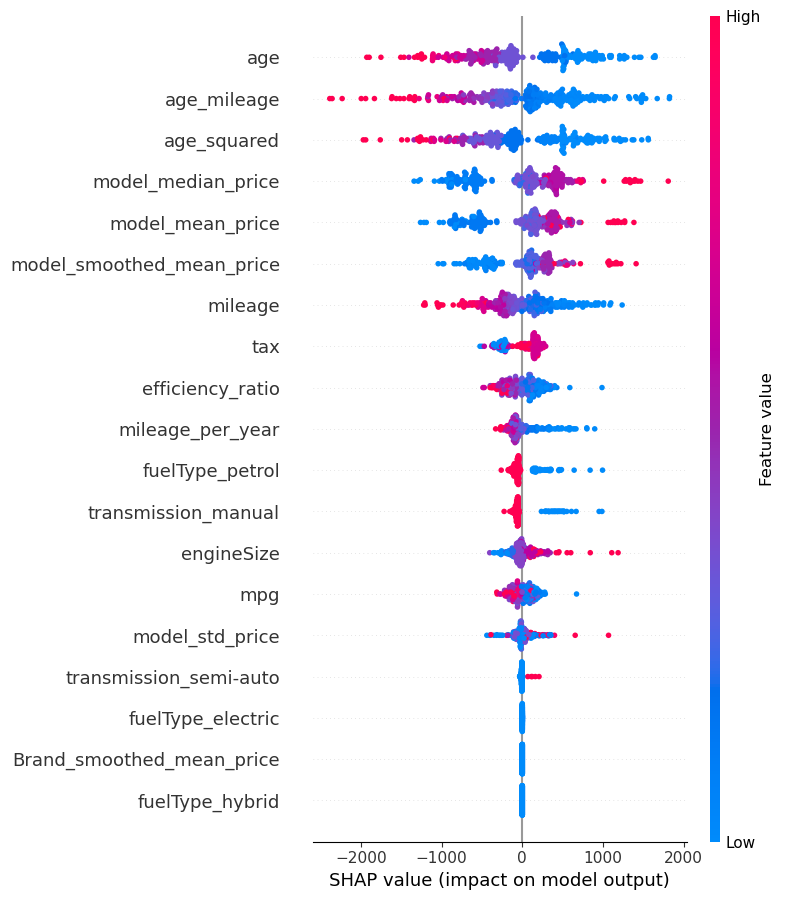

In [54]:
shap.initjs()

sample_opel = X_train_opel_final.sample(300, random_state=69)

explainer_opel = shap.TreeExplainer(rf_opel)
shap_values_opel = explainer_opel.shap_values(sample_opel)

shap.summary_plot(shap_values_opel, sample_opel)

SHAP Pattern Interpretation (Opel Model):

**High Impact Features:**

- **Age, age_mileage, age_squared**: These features exhibit a wide SHAP value distribution 
  (from -2000 to +2000) with a clear color separation. Low values (blue) tend to have a positive 
  impact, while high values (red) have a negative impact. This indicates that younger vehicles 
  significantly increase the predicted price.

- **Model_median/mean/smoothed_mean_price**: High values (red) increase predicted prices, 
  while low values (blue) decrease them. These features act as crucial market benchmarks for 
  pricing.

- **Mileage**: Shows a broad distribution where high mileage (red) lowers the predicted price 
  and low mileage (blue) increases it, consistent with expected depreciation effects.

**Medium Impact Features:**

- **Tax, efficiency_ratio, mileage_per_year**: These features are more concentrated around zero, 
  indicating a moderate but still relevant impact on predictions.

- **fuelType_petrol, transmission_manual**: Display more defined patterns, suggesting that 
  specific categories have consistent effects on price.

**Low Impact Features:**

- **fuelType_electric, Brand_smoothed_mean_price, fuelType_hybrid**: These show very narrow 
  distributions around zero, indicating low relevance in the Opel dataset, likely due to the 
  low prevalence of these segments.

**Opel Market Characteristics:**

The Opel model appears to be dominated by traditional depreciation factors such as age and 
mileage, along with model-specific price benchmarks. The minimal impact of alternative fuel 
types suggests that this market segment is still focused primarily on conventional engines.


#### SHAP on Mercedes

In [49]:
X_train_mercedes = X_train_rfed[X_train_rfed['Brand'] == 'mercedes'].copy()
y_train_mercedes = y_train[X_train_rfed['Brand'] == 'mercedes'].copy()


scaler_mercedes = RobustScaler()
X_train_mercedes_num = pd.DataFrame(
    scaler_mercedes.fit_transform(X_train_mercedes[numeric_cols]),
    columns=numeric_cols,
    index=X_train_mercedes.index
)

In [50]:
X_train_mercedes_cat = pd.get_dummies(X_train_mercedes[categorical_cols], drop_first=True)
X_train_mercedes_final = pd.concat([X_train_mercedes_num, X_train_mercedes_cat], axis=1)


In [51]:
rf_mercedes = RandomForestRegressor(
    n_estimators=2000,
    max_depth=30,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features=0.7,
    bootstrap= True,
    criterion= "squared_error",
    random_state=69,
    n_jobs=-1
)


rf_mercedes.fit(X_train_mercedes_final, y_train_mercedes)

,n_estimators,2000
,criterion,'squared_error'
,max_depth,30
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
X_val_mercedes = X_val_rfed[X_val_rfed['Brand'] == 'mercedes'].copy()
y_val_mercedes = y_val[X_val_rfed['Brand'] == 'mercedes'].copy()

X_val_mercedes_num = pd.DataFrame(
    scaler_mercedes.transform(X_val_mercedes[numeric_cols]),
    columns=numeric_cols,
    index=X_val_mercedes.index
)

X_val_mercedes_cat = pd.get_dummies(X_val_mercedes[categorical_cols], drop_first=True)

X_val_mercedes_cat = X_val_mercedes_cat.reindex(columns=X_train_mercedes_cat.columns, fill_value=0)

X_val_mercedes_final = pd.concat([X_val_mercedes_num, X_val_mercedes_cat], axis=1)

y_pred_mercedes = rf_mercedes.predict(X_val_mercedes_final)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\shap\explainers\_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


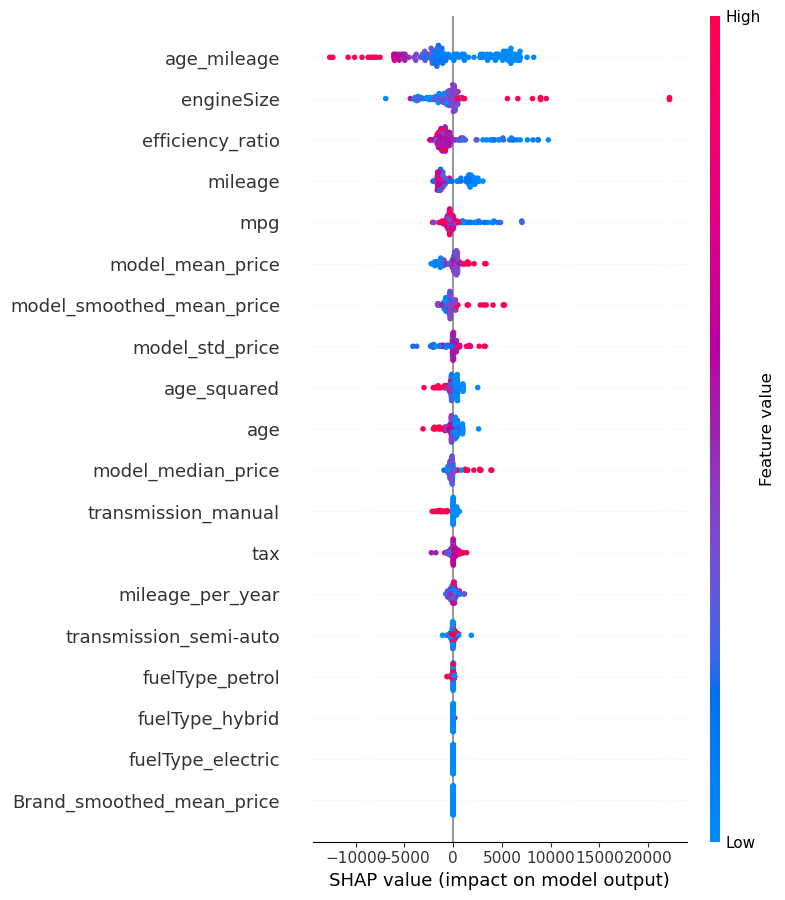

In [57]:
shap.initjs()

sample_mercedes = X_train_mercedes_final.sample(150, random_state=69)

explainer_mercedes = shap.TreeExplainer(
    rf_mercedes,
    feature_perturbation="interventional",
    model_output="raw"
)

shap_values_mercedes = explainer_mercedes.shap_values(
    sample_mercedes,
    approximate=True
)

shap.summary_plot(shap_values_mercedes, sample_mercedes)


SHAP Pattern Interpretation (Mercedes Model):

**High Impact Features:**

- **age_mileage**: This feature dominates the model, with SHAP values ranging from -10,000 
  to nearly +20,000, showing the most significant impact. Low values (blue) have a strong 
  positive effect on predicted prices.

- **engineSize**: High values (red) substantially increase predicted prices, reflecting the 
  premium segment where larger engines are associated with high-end models.

- **efficiency_ratio**: Displays an inverse pattern compared to Opel, with high values (red) 
  reducing predicted prices. This may indicate that less efficient vehicles in the premium 
  segment are perceived as less desirable.

**Medium Impact Features:**

- **Mileage, mpg, model_mean/smoothed/std/median_price**: These features show more balanced 
  and concentrated distributions, indicating that model-specific price benchmarks are important 
  in the Mercedes segment but less dominant than in Opel.

- **Age, age_squared**: Have a smaller impact compared to the Opel model, suggesting that 
  technical specifications weigh more heavily than simple temporal depreciation in this segment.

**Low Impact Features:**

- **Fuel type features (hybrid, electric) and transmission**: Show minimal impact, concentrated 
  near zero.

**Mercedes Market Characteristics:**

The Mercedes market is characterized by greater complexity in price determination, where 
technical specifications such as engine size and efficiency play a more significant role than 
simple age-related depreciation. The SHAP value scale is roughly ten times larger than for Opel, 
reflecting the wider price range typical of the premium segment.


#### Comparison

**Volume Segment (Opel):**

- **Pricing Strategy:** Focus on age and mileage as primary drivers, with adjustments based 
  on the average model price in the market.
- **Inventory Acquisition:** Prioritize young vehicles with low mileage, given their strong 
  positive impact on value.
- **Marketing:** Highlight vehicle history (single owner, full service record) to positively 
  influence perceived age/mileage.
- **Segmentation:** Create clusters based on model and year, as model-specific price benchmarks 
  are crucial.

**Premium Segment (Mercedes):**

- **Pricing Strategy:** Adopt a more sophisticated approach that considers technical 
  specifications (engine size, equipment) in addition to depreciation factors.
- **Inventory Acquisition:** Carefully evaluate specific configurations, prioritizing larger 
  engines and vehicles with better features, even if older.
- **Marketing:** Emphasize distinctive vehicle characteristics (performance, equipment, options) 
  that significantly influence perceived value.
- **Price Personalization:** Implement a more granular pricing system to capture differences 
  between configurations.

Machine Learning Strategies

**Model-Specific Improvements:**

- **Opel Feature Engineering:**
  - Consider interactions between age and fuel type.
  - Create composite features to better capture value-for-money in the volume segment.
  - Potentially reduce the model by removing low-impact features (e.g., alternative fuel types).

- **Mercedes Feature Engineering:**
  - Develop more sophisticated features to capture premium positioning (AMG, Maybach, standard).
  - Create indicators for premium configurations (optional packages, special trims).
  - Consider interactions between engineSize and efficiency_ratio.

**ML Architecture:**

- **Opel:** A simpler model (e.g., Random Forest or Gradient Boosting with limited depth) 
  may suffice due to relatively linear patterns.
- **Mercedes:** Would benefit from more complex models (Deep Learning or advanced ensembles) 
  to capture non-linear interactions among features.


### XGBoost


XGBoost is widely regarded as one of the most effective models for tabular data, together with
approaches such as TabNet, CatBoost, and LightGBM. To better understand the capabilities of our
pipeline in a realistic setting, we decided to compare our results with one of the standard
reference models in the field.

For this comparison, we relied on the BrandModelTrainer class to balance the training process
across brands, ensuring consistency with the methodology used for the other models.

Note

The purpose of this section is purely experimental and intended for comparative insight.
XGBoost was not used for the final predictions, nor was it involved in model development during
the previous sections of the notebook.


In [64]:
from xgboost import XGBRegressor

In [65]:
XG = XGBRegressor(random_state=69)
XG_trainer = BrandModelTrainer(XG)


XG_trainer.fit(X_train_rfed, y_train)


XG_trainer.evaluate_train(X_train_rfed, y_train)
XG_trainer.evaluate(X_val_rfed, y_val)

XG_trainer.evaluate_train_by_brand(X_train_rfed, y_train)
XG_trainer.evaluate_by_brand(X_val_rfed, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 1056.41
  MAE:  724.68
  R²:   0.9879

Validation Set Performance (Overall):
  RMSE: 1956.01
  MAE:  1223.24
  R²:   0.9579

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
  toyota  3775  535.566778  387.783793 0.992530
 hyundai  2723  556.688258  381.101352 0.991487
    opel  7638  645.718482  472.857400 0.967152
   skoda  3502  651.270228  478.928993 0.988687
    ford 13112  885.518789  651.716039 0.965339
      vw  8479 1020.391478  732.945888 0.982503
    audi  5970 1204.989876  878.853704 0.989358
     bmw  6037 1244.474892  887.498457 0.987986
mercedes  9542 1589.368601 1141.233271 0.977461

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1219.682420  804.095701 0.882846
 hyundai  687 

,Brand,N,RMSE,MAE,R²
7,opel,1907,1219.682420,804.095701,0.882846
5,hyundai,687,1314.944706,925.447153,0.949667
1,ford,3279,1425.243114,904.842734,0.910580
8,skoda,881,1439.542923,1031.494385,0.945671
3,toyota,941,1449.324582,912.809944,0.953526
0,vw,2125,1712.526986,1151.497635,0.951457
6,audi,1490,2368.667494,1630.463790,0.956104
2,bmw,1505,2673.162522,1635.057302,0.944347
4,mercedes,2380,2773.042457,1826.142513,0.930259


The results obtained with XGBoost are slightly better than those of the baseline Random Forest.

It is reasonable to expect that further performance gains could be achieved through a more
careful and targeted hyperparameter tuning process. Even though the improvements observed here
are modest, they are consistent and meaningful.

For this reason, in a real world production setting, XGBoost would likely be the preferable
choice due to its strong performance, flexibility, and well known robustness on tabular data.


### General model



As can be observed, the main design choice in this notebook was to create nine smaller, 
brand-specific models that together form the final prediction framework.

We still questioned whether a single general model could be a viable alternative, so we tested 
this approach as well. 

For this experiment, the hyperparameters were set to the best averaged values identified during 
the random search, ensuring a fair comparison with the specialized models.

The class created for the previous tests wasn't used since we cared about putting all the brands together.

In [66]:

numeric_cols = X_train_rfed.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'price'] 

categorical_cols = ['Brand', 'transmission', 'fuelType']

preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('estimator', RandomForestRegressor(
        n_estimators=800,
        max_depth=20,
        min_samples_split=3,
        min_samples_leaf=2,
        max_features=0.4,
        min_impurity_decrease=0.01,
        max_samples=None,
        criterion="squared_error",
        bootstrap=True,
        random_state=69,
        n_jobs=-1
    ))
])


rf_pipeline.fit(X_train_rfed, y_train)


y_pred_val = rf_pipeline.predict(X_val_rfed)



rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print(f'RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}')


RMSE: 1991.92, MAE: 1227.02, R²: 0.9563


The results highlight several interesting points:

- The predictions are quite similar, which is expected given that the forest is built by splitting on random subsets of features. Since we used many trees, the predictions tend to average out, leading to relatively consistent outcomes.

- Despite the similarity, the general model still showed worse performance (about 15 MAE higher), likely due to cars with similar specifications having noticeably different prices.

- Training the general model took significantly longer. One-hot encoding the Brand feature added 9 extra columns, and splits had to be computed over many more rows. In a real-world deployment, such as a car dealership where we might want to retrain the model whenever new cars are added or sold, a faster training process could be more practical.